# Graph Neural Networks for S&P 500 Return Prediction

> **How to run:** Execute cells top-to-bottom. Best hyperparameters are already set in each section. The full tuning code that produced them is in the Appendix.

## Setup

In [1]:
# To get access to the data files from github in Google Colab
!git clone https://github.com/math869c/graph_representation_st457.git

# set the folder to get access to the data
import os
os.chdir('/content') # to avoid error if rerun
os.chdir('./graph_representation_st457') # gives them access to everything in the folder

Cloning into 'graph_representation_st457'...
remote: Enumerating objects: 214, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 214 (delta 9), reused 11 (delta 1), pack-reused 179 (from 1)
Receiving objects: 100% (214/214), 38.65 MiB | 18.63 MiB/s, done.
Resolving deltas: 100% (102/102), done.


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torch.optim as optim
import json
import optuna
import time
import copy


In [4]:
from keras.layers import *
import torch.nn as nn
import torch
import torch.nn.functional as F

# order of blocks
# 1. LSTM
# 2. TGC
# 3. GAT

# LSTM model
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_units, output_size, dropout_rate):
        super().__init__()

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_units,
            batch_first=True
        )
        self.dropout1 = nn.Dropout(dropout_rate)

        self.lstm2 = nn.LSTM(
            input_size=hidden_units,
            hidden_size=hidden_units * 2,
            batch_first=True
        )
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc1 = nn.Linear(hidden_units * 2, hidden_units)
        self.relu = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_units, output_size)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)

        x, _ = self.lstm2(x)
        x = x[:, -1, :]
        x = self.dropout2(x)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout3(x)
        x = self.fc2(x)
        return x




# The TGC consists of 3 building blocks
# Block 1: The LSTM Encoder
class CompanyEncoder(nn.Module):
    def __init__(self, num_features, emb_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=emb_dim, batch_first=True)

    def forward(self, x):
        # x: [T, L, N, F]
        # Letter for dimensions: T is time periods, L length of sequences, N number of firms, F number of features, B batch size
        B, L, N, F = x.shape

        x = x.permute(0, 2, 1, 3).reshape(B * N, L, F)   # [B*N, L, F]

        _, (h_n, _) = self.lstm(x)
        E = h_n[-1].reshape(B, N, -1)                    # [B, N, emb_dim]
        return E

# Block 2: The Graph Layer
class TemporalMultiRelationGCN(nn.Module):
    def __init__(self, in_dim, out_dim, num_relations):
        super().__init__()
        self.edge_linear = nn.Linear(num_relations, 1)

    def forward(self, E, A):
        # E: [B, N, d]
        # A: [N, N, K]
        # setiup
        B, N, d = E.shape
        E_E = torch.matmul(E, E.transpose(1, 2)) # Same as e_i^T e_j in paper

        edge_score = self.edge_linear(A).squeeze(-1)
        edge_score = torch.relu(edge_score) # this is phi in the paper

        deg = edge_score.sum(dim=0, keepdim=True) + 1e-6
        edge_weight = edge_score / deg                 # phi/d

        weights = E_E * edge_weight.unsqueeze(0)       # Combine: part_1 = e_i^T e_j @ phi/d
        H = torch.matmul(weights, E)                   # combine: part_1@ e_j

        return H

# Block 3: The Dense Layer
# I think I did one extra ReLu/linear layer too much
class Header(nn.Module):
  def __init__(self, gcn_dim):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(gcn_dim, 64),
        nn.ReLU(), # I Think this should be commented out
        nn.Dropout(0.2),  # I Think this should be commented out
        nn.Linear(64, 1)  # I Think this should be commented out
    )

  def forward(self, x):
    return self.model(x)

class TGCModel(nn.Module):
    def __init__(self, num_features, emb_dim, gcn_dim, num_relations):
        super().__init__()
        self.encoder = CompanyEncoder(num_features, emb_dim)
        self.tgc = TemporalMultiRelationGCN(emb_dim, gcn_dim, num_relations)
        self.head = Header(gcn_dim)

    def forward(self, x, A):
        # x: [B, L, N, F]
        # A: [N, N, K]
        E = self.encoder(x)               # Embedding layer
        H = self.tgc(E, A)                # combines embeddings and adjacency matrix
        y_hat = self.head(H).squeeze(-1)  # makes N predictions
        return y_hat

# GAT model
class GATLayer(nn.Module):
    """
    From seminar 7 with minor adjustments
    """

    def __init__(self, c_in, c_out, num_relations, num_heads=1, concat_heads=True, alpha=0.2):
        """
        Inputs:
            c_in - Dimensionality of input features
            c_out - Dimensionality of output features
            num_heads - Number of heads, i.e. attention mechanisms to apply in parallel. The
                        output features are equally split up over the heads if concat_heads=True.
            concat_heads - If True, the output of the different heads is concatenated instead of averaged.
            alpha - Negative slope of the LeakyReLU activation.
        """
        super().__init__()
        self.num_heads = num_heads
        self.concat_heads = concat_heads
        self.num_relations = num_relations

        if self.concat_heads:
            assert (
                c_out % num_heads == 0
            ), "Number of output features must be a multiple of the count of heads."
            c_out = c_out // num_heads

        # Sub-modules and parameters needed in the layer
        self.projections = nn.ModuleList([nn.Linear(c_in, c_out * num_heads, bias=False) for _ in range(num_relations)])
        self.a = nn.Parameter(torch.Tensor(num_relations, num_heads, 2 * c_out))
        self.leakyrelu = nn.LeakyReLU(alpha)

        # Initialization from the original implementation
        for proj in self.projections:
            nn.init.xavier_uniform_(proj.weight.data, gain=1.414)
        nn.init.xavier_uniform_(self.a.data, gain=1.414)

    def forward(self, node_feats, adj_matrix, print_attn_probs=False):
        """
        Inputs:
            node_feats - Input features of the node. Shape: [batch_size, c_in]
            adj_matrix - Adjacency matrix including self-connections. Shape: [batch_size, num_nodes, num_nodes]
            print_attn_probs - If True, the attention weights are printed during the forward pass (for debugging purposes)
        """
        batch_size, num_nodes = node_feats.size(0), node_feats.size(1)
        R = self.num_relations
        if adj_matrix.dim() == 3:
            adj_matrix = adj_matrix.unsqueeze(0).repeat(batch_size, 1, 1, 1)

        # We have only changed this little part to include multiple relations
        rel_outputs = []
        node_feats_input = node_feats

        for r in range(R):
            adj_r = adj_matrix[:,:,:, r]

            # Apply linear layer and sort nodes by head
            node_feats_r = self.projections[r](node_feats_input)

            node_feats_r = node_feats_r.view(batch_size, num_nodes, self.num_heads, -1)

            # We need to calculate the attention logits for every edge in the adjacency matrix
            # Doing this on all possible combinations of nodes is very expensive
            # => Create a tensor of [W*h_i||W*h_j] with i and j being the indices of all edges
            edges = adj_r.nonzero(as_tuple=False)  # Returns indices where the adjacency matrix is not 0 => edges

            node_feats_flat = node_feats_r.view(batch_size * num_nodes, self.num_heads, -1)
            edge_indices_row = edges[:, 0] * num_nodes + edges[:, 1]
            edge_indices_col = edges[:, 0] * num_nodes + edges[:, 2]
            a_input = torch.cat(
                [
                    torch.index_select(
                        input=node_feats_flat, index=edge_indices_row, dim=0
                    ),
                    torch.index_select(
                        input=node_feats_flat, index=edge_indices_col, dim=0
                    ),
                ],
                dim=-1,
            )  # Index select returns a tensor with node_feats_flat being indexed at the desired positions along dim=0

            # Calculate attention MLP output (independent for each head)
            attn_logits = torch.einsum("ehc,hc->eh", a_input, self.a[r])
            attn_logits = self.leakyrelu(attn_logits)

            # Map list of attention values back into a matrix
            attn_matrix = attn_logits.new_full((batch_size, num_nodes, num_nodes, self.num_heads), -9e15)
            mask = adj_r != 0
            attn_matrix[mask[..., None].repeat(1, 1, 1, self.num_heads)] = attn_logits.reshape(-1)

            # Weighted average of attention
            attn_probs = nn.functional.softmax(attn_matrix, dim=2)

            if print_attn_probs:
                print(
                    "Attention probs\n", attn_probs.permute(0, 3, 1, 2)
                )  # show the attention weight for each edge
            out_r = torch.einsum("bijh,bjhc->bihc", attn_probs, node_feats_r)
            rel_outputs.append(out_r)

        # sum relation-specific messages
        node_feats = torch.stack(rel_outputs, dim=0).sum(dim=0)

        # If heads should be concatenated, we can do this by reshaping. Otherwise, take mean
        if self.concat_heads:
            node_feats = node_feats.reshape(batch_size, num_nodes, -1)
        else:
            node_feats = node_feats.mean(dim=2)

        return node_feats

class GAT(nn.Module):
    def __init__(self, c_in, c_hidden, c_out, num_relations, num_heads=4, alpha=0.2):
        super().__init__()

        self.gat1 = GATLayer(
            c_in=c_in,
            c_out=c_hidden,
            num_relations = num_relations,
            num_heads=num_heads,
            concat_heads=True,
            alpha=alpha
        )

        self.gat2 = GATLayer(
            c_in=c_hidden,
            c_out=c_out,
            num_relations = num_relations,
            num_heads=1,
            concat_heads=False,
            alpha=alpha
        )

    def forward(self, x, adj):
        x = self.gat1(x, adj)      # [B, N, c_hidden]
        x = nn.functional.elu(x)
        x = self.gat2(x, adj)      # [B, N, c_out]
        x = x.squeeze(-1)
        return x

# RotatE model
class RotatE(nn.Module):
    def __init__(self, num_relations, emb_dim):
        super().__init__()

        self.emb_dim = emb_dim

        # relation phases (angles)
        self.phase = nn.Parameter(torch.randn(num_relations, emb_dim))

    def score_triples(self, z, edge_index, edge_type):
            """
            z: (B, N, 2*d)
            edge_index: (E, 2)
            edge_type: (E,)
            returns: (B, E)
            """
            B, N, D = z.shape
            d = D // 2
            assert D == 2 * self.emb_dim, f"Expected last dim {2*self.emb_dim}, got {D}"

            z_re = z[..., :d]
            z_im = z[..., d:]

            u = edge_index[:, 0]
            v = edge_index[:, 1]
            r = edge_type

            zu_re = z_re[:, u, :]
            zu_im = z_im[:, u, :]
            zv_re = z_re[:, v, :]
            zv_im = z_im[:, v, :]

            phase = self.phase[r]
            r_re = torch.cos(phase).unsqueeze(0)
            r_im = torch.sin(phase).unsqueeze(0)

            rot_re = zu_re * r_re - zu_im * r_im
            rot_im = zu_re * r_im + zu_im * r_re

            diff_re = rot_re - zv_re
            diff_im = rot_im - zv_im

            score = -(diff_re.pow(2) + diff_im.pow(2)).sum(dim=-1)
            return score

    def forward(self, z, edge_index, edge_type):
        return self.score_triples(z, edge_index, edge_type)

class GAT_RotatE(nn.Module):
    def __init__(self, c_in, c_hidden, emb_dim, num_relations, num_heads=4, alpha=0.2):
        super().__init__()
        self.encoder = GAT(
            c_in=c_in,
            c_hidden=c_hidden,
            c_out=2 * emb_dim,
            num_relations=num_relations,
            num_heads=num_heads,
            alpha=alpha
        )
        self.regressor = nn.Linear(2 * emb_dim, 1)
        self.rotate = RotatE(num_relations=num_relations, emb_dim=emb_dim)

    def forward(self, x, adj):
        z = self.encoder(x, adj)                 # (B, N, 2*emb_dim)
        y_hat = self.regressor(z).squeeze(-1)    # (B, N)
        return y_hat, z

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import copy
from model_classes import *
import torch.optim as optim
# order of code
# 1. create features and data to run models
# 2. training functions for LSTM
# 3. training functions for TGC
# 4. training functions for GAT
# 5. training functions for GAT+trans
# 6. metrics functions
# 7. Plotting functions for evalu

# 1. create features and data to run models
def moving_average(a, window):
    '''create moving average features, what they do in the paper'''
    return np.apply_along_axis(lambda x: np.convolve(x, np.ones(window)/window, mode='valid'), axis=0, arr=a)


def make_features(x, window = [5, 10, 20, 30]):
    '''Create features of moving averages'''
    x_returns = np.diff(np.log(x),axis=0)
    ma_dict = {w: moving_average(x_returns, w) for w in window}
    min_T = min(ma.shape[0] for ma in ma_dict.values())
    x_trim = x_returns[-min_T:]
    ma_trimmed = [ma_dict[w][-min_T:] for w in window]
    features = np.stack([x_trim] + ma_trimmed, axis=-1)
    return features

def create_data(x, batch_size=32, flatten_data = True, flatten_time_features = False, shuffle_train= True):
    '''Prepare data for models'''
    features = make_features(x, window = [5, 10, 20, 30])
    # target all prices at time t
    target = features[:, :, 0]

    # split up the data
    n = len(target)
    train_end = n // 2
    val_end = train_end + n // 4
    train_raw = features[:train_end,:,:]
    val_raw   = features[train_end:val_end,:,:]
    test_raw  = features[val_end:,:, :]

    # Get original shapes for reshaping back
    train_shape = train_raw.shape
    val_shape = val_raw.shape
    test_shape = test_raw.shape

    # Reshape 3D data to 2D for StandardScaler (combine first two dimensions)
    train_reshaped = train_raw.reshape(-1, train_shape[-1])
    val_reshaped = val_raw.reshape(-1, val_shape[-1])
    test_reshaped = test_raw.reshape(-1, test_shape[-1])
    sc = StandardScaler()
    train_scaled_reshaped = sc.fit_transform(train_reshaped)
    val_scaled_reshaped   = sc.transform(val_reshaped)
    test_scaled_reshaped  = sc.transform(test_reshaped)

    # Reshape back to 3D after scaling
    train_scaled = train_scaled_reshaped.reshape(train_shape)
    val_scaled   = val_scaled_reshaped.reshape(val_shape)
    test_scaled  = test_scaled_reshaped.reshape(test_shape)

    # Concatenate along the time dimension (axis=0)
    full_scaled = np.concatenate((train_scaled, val_scaled, test_scaled), axis=0)

    seq_len = 8
    X, y = [], []
    for i in range(seq_len, len(full_scaled)):
        X.append(full_scaled[i-seq_len:i, :,:])
        y.append(full_scaled[i, :, 0])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    train_idx = train_end - seq_len
    val_idx   = val_end - seq_len

    X_train, y_train = X[:train_idx], y[:train_idx]
    X_val,   y_val   = X[train_idx:val_idx], y[train_idx:val_idx]
    X_test,  y_test  = X[val_idx:], y[val_idx:]

    # keras can max input 3D and not 4D
    if flatten_data:
        (T, L, N, F) = X_train.shape
        X_train = X_train.reshape(T,L,N*F)
        (T, L, N, F) = X_val.shape
        X_val = X_val.reshape(T,L,N*F)
        (T, L, N, F) = X_test.shape
        X_test = X_test.reshape(T,L,N*F)
    elif flatten_time_features:
        (T, L, N, F) = X_train.shape
        X_train = X_train.reshape(T,N,L*F)
        (T, L, N, F) = X_val.shape
        X_val = X_val.reshape(T,N,L*F)
        (T, L, N, F) = X_test.shape
        X_test = X_test.reshape(T,N,L*F)

    # Convert to torch tensors and make into mini-batches (otherwise it can crash as it uses too much RAM)
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)

    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    y_val_t   = torch.tensor(y_val, dtype=torch.float32)
    y_test_t  = torch.tensor(y_test, dtype=torch.float32)

    print(X_train_t.shape)  # (T_train, 8, 460, 5)
    print(y_train_t.shape)  # (T_train, 460)

    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t, y_val_t)
    test_ds  = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle_train) # this includes all the data makes it into batches
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader

# 2. training functions for LSTM and TGC
def directional_accuracy(preds, targets):
    return ((preds > 0) == (targets > 0)).float().mean().item()

def train_one_epoch_LSTM(model, dataloader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    n = 0

    for X_batch, y_batch in dataloader:

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        running_acc += directional_accuracy(preds.detach(), y_batch) * batch_size
        n += batch_size

    return running_loss / n, running_acc / n


def evaluate_LSTM(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    n = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            batch_size = X_batch.size(0)
            running_loss += loss.item() * batch_size
            running_acc += directional_accuracy(preds, y_batch) * batch_size
            n += batch_size

    return running_loss / n, running_acc / n

def predict_final_model(model, dataloader):
    model.eval()
    preds = []

    with torch.no_grad():
        for X_batch, _ in dataloader:
            preds.append(model(X_batch).numpy())

    return np.concatenate(preds, axis=0)

def train_with_validation_LSTM(model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=10):
    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    history_metrics = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch_LSTM(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate_LSTM(model, val_loader, criterion)

        history_metrics['train_loss'].append(train_loss)
        history_metrics['train_acc'].append(train_acc)
        history_metrics['val_loss'].append(val_loss)
        history_metrics['val_acc'].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history_metrics, best_val_loss



# 3. training functions for TGC
# functions for training, evaluating and predicting
def train_one_epoch(model, loader, A, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        optimizer.zero_grad()

        pred = model(x_batch, A)        # [B, N]
        loss = criterion(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def evaluate(model, loader, A, criterion):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        pred = model(x_batch, A)
        loss = criterion(pred, y_batch)

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def predict(model, loader, A):
    model.eval()
    preds = []
    ys = []

    for x_batch, y_batch in loader:
        pred = model(x_batch, A)

        preds.append(pred)
        ys.append(y_batch)

    preds = torch.cat(preds, dim=0)
    return preds

def train_with_validation(model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=10):
    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0

    history_metrics = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history_metrics['train_loss'].append(train_loss)
        history_metrics['train_acc'].append(train_acc)
        history_metrics['val_loss'].append(val_loss)
        history_metrics['val_acc'].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history_metrics, best_val_loss

def training_loop_TGC(train_loader, val_loader, test_loader, y_test, adj_matrix, F, emb_dim, K_num_relations, num_epochs = 20):
    # do the training
    dict_adj_matrices = {'sector':    {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,0].unsqueeze(-1), 'pred':np.empty},
                        'industry':  {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,1].unsqueeze(-1), 'pred':np.empty},
                        'corre':     {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,2].unsqueeze(-1), 'pred':np.empty},
                        'everything':{'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,:],               'pred':np.empty} }

    for key in dict_adj_matrices.keys():
        print(f'Doing model: {key}')
        A_loop = dict_adj_matrices[key]['matrix']
        K_num_relations = A_loop.shape[-1] # This will be 1 for single relations, and 3 for 'everything'

        model_TGC = TGCModel(num_features=F, emb_dim=emb_dim, gcn_dim=emb_dim, num_relations=K_num_relations)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model_TGC.parameters(), lr=1e-3)

        for epoch in range(num_epochs):
          train_loss = train_one_epoch(model_TGC, train_loader, A_loop, optimizer, criterion)
          val_loss = evaluate(model_TGC, val_loader, A_loop, criterion)

          print(f"Epoch {epoch+1:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        dict_adj_matrices[key]['model'] = model_TGC
        pred_test_TGC = predict(model_TGC, test_loader, A_loop)

        dict_adj_matrices[key]['pred'] = pred_test_TGC

        dict_adj_matrices[key]['MSE'] = np.mean((y_test-pred_test_TGC.numpy())**2,axis=0)

        metrics = compute_metrics(y_test, pred_test_TGC.numpy())
        dict_adj_matrices[key]['metrics'] = metrics

    return dict_adj_matrices

# 4. training functions for GAT
def train_one_epoch_GAT(model, loader, A_single_graph, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        optimizer.zero_grad()

        current_batch_size = x_batch.size(0)
        # Replicate the single graph adjacency matrix for the current batch
        A_batched = A_single_graph.unsqueeze(0).repeat(current_batch_size, 1, 1, 1)

        pred = model(x_batch, A_batched)        # [B, N]
        loss = criterion(pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def evaluate_GAT(model, loader, A_single_graph, criterion):
    model.eval()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        current_batch_size = x_batch.size(0)
        # Replicate the single graph adjacency matrix for the current batch
        A_batched = A_single_graph.unsqueeze(0).repeat(current_batch_size, 1, 1, 1)

        pred = model(x_batch, A_batched)
        loss = criterion(pred, y_batch)

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def predict_GAT(model, loader, A_single_graph):
    model.eval()
    preds = []
    ys = []

    for x_batch, y_batch in loader:
        current_batch_size = x_batch.size(0)
        # Replicate the single graph adjacency matrix for the current batch
        A_batched = A_single_graph.unsqueeze(0).repeat(current_batch_size, 1, 1, 1)

        pred = model(x_batch, A_batched)

        preds.append(pred.cpu())
        ys.append(y_batch)

    preds = torch.cat(preds, dim=0)
    return preds

# 5. training functions for GAT+RotatE
def sample_negative_edges(edge_index, num_nodes):
    neg_edge_index = edge_index.clone()
    neg_edge_index[:, 1] = torch.randint(
        0, num_nodes, (edge_index.size(0),), device=edge_index.device
    )
    return neg_edge_index

def rotate_loss_chunked(model, z, edge_index, edge_type, chunk_size=4000):
    """
    z: (B, N, 2*d)
    edge_index: (E, 2)
    edge_type: (E,)
    """
    num_nodes = z.size(1)
    E = edge_index.size(0)

    total_loss = 0.0
    n_chunks = 0

    for start in range(0, E, chunk_size):
        end = min(start + chunk_size, E)

        ei = edge_index[start:end]
        et = edge_type[start:end]

        pos_score = model.rotate.score_triples(z, ei, et)
        neg_ei = sample_negative_edges(ei, num_nodes)
        neg_score = model.rotate.score_triples(z, neg_ei, et)

        loss_pos = -F.logsigmoid(pos_score).mean()
        loss_neg = -F.logsigmoid(-neg_score).mean()
        loss = loss_pos + loss_neg

        total_loss = total_loss + loss
        n_chunks += 1

    return total_loss / n_chunks

def build_edges(adj_matrix):
    edge_index_list = []
    edge_type_list = []

    R = adj_matrix.shape[-1]
    for r in range(R):
        adj_r = adj_matrix[:, :, r]
        edges = (adj_r > 0).nonzero(as_tuple=False)

        # remove self loops
        edges = edges[edges[:, 0] != edges[:, 1]]

        edge_index_list.append(edges)
        edge_type_list.append(
            torch.full((edges.shape[0],), r, dtype=torch.long)
        )

    edge_index = torch.cat(edge_index_list, dim=0)
    edge_type = torch.cat(edge_type_list, dim=0)
    return edge_index, edge_type


def train_one_epoch_GAT_RotatE(model, loader, A_single_graph, edge_index, edge_type, optimizer, lambda_rotate=0.1):
    model.train()
    total_loss = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        optimizer.zero_grad()

        y_hat, z = model(x_batch, A_single_graph)

        loss_forecast = F.mse_loss(y_hat, y_batch)
        loss_graph = rotate_loss_chunked(model, z, edge_index, edge_type)

        loss = loss_forecast + lambda_rotate * loss_graph
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
        total_count += x_batch.size(0)

    return total_loss / total_count

@torch.no_grad()
def evaluate_GAT_RotatE(model, loader, A_single_graph):
    model.eval()
    total_mse = 0.0
    total_count = 0

    for x_batch, y_batch in loader:
        y_hat, _ = model(x_batch, A_single_graph)
        total_mse += F.mse_loss(y_hat, y_batch).item()
        total_count += x_batch.size(0)

    return total_mse / total_count

@torch.no_grad()
def predict_GAT_RotatE(model, loader, A_single_graph):
    model.eval()
    preds = []

    for x_batch, _ in loader:
        y_hat, _ = model(x_batch, A_single_graph)
        preds.append(y_hat.cpu())

    return torch.cat(preds, dim=0)



# 6. metrics functions
def compute_metrics(y_true, y_pred):
    # y_true: numpy array [T, N] - actual returns
    # y_pred: numpy array [T, N] - predicted returns

    # Convert to direction labels (1 = up, 0 = down)
    y_true_dir = (y_true > 0).astype(int)
    y_pred_dir = (y_pred > 0).astype(int)

    # Flatten for sklearn
    y_true_flat = y_true_dir.flatten()
    y_pred_flat = y_pred_dir.flatten()

    # Classification metrics
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    f1 = f1_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_true_flat, y_pred_flat)

    # Trading strategy: buy if predicted up, short if predicted down
    trade_sign = np.where(y_pred_dir == 1, 1, -1)
    strategy_returns = y_true * trade_sign
    daily_returns = strategy_returns.mean(axis=1)

    # Financial metrics
    return_ratio = daily_returns.sum()
    std = daily_returns.std()
    sharpe = (daily_returns.mean() / std) * np.sqrt(252) if std > 0 else 0.0

    # MSE
    MSE = np.mean((y_true - y_pred) ** 2)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'mcc': mcc,
        'return_ratio': return_ratio,
        'sharpe': sharpe,
        'MSE': MSE
    }

# 7. Plotting functions for evalu
def plot_results(y_test, pred, open_prices_interp, nr_firms=10):
    seq_len = 8
    max_left_from_ma = int(30 // 2 - 1)
    start_date_for_plot = 1 + max_left_from_ma + seq_len
    tickers = open_prices_interp.columns
    dates = open_prices_interp.index[start_date_for_plot:start_date_for_plot + len(y_test)]
    n_ticks = 8
    tick_idx = np.linspace(0, len(dates) - 1, n_ticks, dtype=int)
    tick_labels = dates[tick_idx]

    for i in range(nr_firms):
        plt.plot(dates, y_test[:, i], color='red', label='Real Stock Price')
        plt.plot(dates, pred[:, i], color='blue', label='Predicted Stock Price')
        plt.xlabel('Time')
        plt.ylabel('S&P 500 Open Price')
        plt.title(f"Firm: {tickers[i]}")
        plt.xticks(ticks=tick_labels, labels=[str(d)[:10] for d in tick_labels], rotation=45)
        plt.tight_layout()
        plt.legend()
        plt.show()

def print_box_plots(MSE_dict):
    plt.figure(figsize=(12,5))

    val_list = []
    label_list = []
    for key, val in MSE_dict.items():
        val_list.append(val)
        label_list.append(key)

    plt.boxplot(val_list, labels=label_list)

    plt.title("MSE comparison across models")
    plt.ylabel("MSE")
    plt.show()

# 1. LSTM

## Load data for LSTM

In [6]:
# Stock prices
open_prices_interp = pd.read_csv('data_folder/open_prices_interp.csv', index_col=0)
# into numpy
x = open_prices_interp.to_numpy()
tickers_with_data = open_prices_interp.columns

# Load graph data
with open("data_folder/firm_industry.json", "r") as f:
    firm_industry_dict = json.load(f)
A = np.load("data_folder/adjacency_matrix.npy")
adj_matrix = torch.tensor(A, dtype=torch.float32)

# make training data
batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(x,
                                                                                                        batch_size =batch_size,
                                                                                                        flatten_data = True, # Should be True for LSTM, False for GTC and GAT
                                                                                                        flatten_time_features=False # Should be True for GAT, False for LSTM and GTC
                                                                                                        )

torch.Size([984, 8, 2300])
torch.Size([984, 460])


## Load LSTM model

In [7]:
# Best hyperparameters from Optuna tuning — 30 trials (see Appendix A.1)
# Best trial: val_loss=2.6131, test_loss=1.5549
best_params_LSTM = {
    'lstm_units':    128,
    'dropout_rate':  0.4641790920735855,
    'learning_rate': 0.0008481129576641046,
    'batch_size':    32,
    'epochs':        16,
    'patience':      8
}

In [8]:
# this is j
output_size = y_train.shape[1]
input_size = X_train.shape[2]

model = LSTMRegressor(
    input_size=input_size,
    hidden_units=best_params_LSTM['lstm_units'],
    output_size=output_size,
    dropout_rate=best_params_LSTM['dropout_rate']
)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=best_params_LSTM['learning_rate'])

## Train LSTM Model

In [9]:
model_LSTM, history_metrics_LSTM, best_val_loss_LSTM = train_with_validation_LSTM(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=20,
    patience=10
)

test_loss_LSTM, _ = evaluate_LSTM(model_LSTM, test_loader, criterion)
print("Best validation loss:", best_val_loss_LSTM)
print("Test loss:", test_loss_LSTM)

Epoch 1/20 | Train Loss: 1.0064 Acc: 0.5028 | Val Loss: 2.6150 Val Acc: 0.4996
Epoch 2/20 | Train Loss: 1.0034 Acc: 0.5080 | Val Loss: 2.6146 Val Acc: 0.5001
Epoch 3/20 | Train Loss: 0.9989 Acc: 0.5193 | Val Loss: 2.6149 Val Acc: 0.5118
Epoch 4/20 | Train Loss: 0.9890 Acc: 0.5322 | Val Loss: 2.6189 Val Acc: 0.5097
Epoch 5/20 | Train Loss: 0.9758 Acc: 0.5523 | Val Loss: 2.6282 Val Acc: 0.5078
Epoch 6/20 | Train Loss: 0.9629 Acc: 0.5651 | Val Loss: 2.6566 Val Acc: 0.5035
Epoch 7/20 | Train Loss: 0.9490 Acc: 0.5847 | Val Loss: 2.6417 Val Acc: 0.4993
Epoch 8/20 | Train Loss: 0.9355 Acc: 0.5978 | Val Loss: 2.6931 Val Acc: 0.4987
Epoch 9/20 | Train Loss: 0.9220 Acc: 0.5977 | Val Loss: 2.7021 Val Acc: 0.5164
Epoch 10/20 | Train Loss: 0.9061 Acc: 0.6060 | Val Loss: 2.6795 Val Acc: 0.4984
Epoch 11/20 | Train Loss: 0.8988 Acc: 0.6147 | Val Loss: 2.7237 Val Acc: 0.4987
Epoch 12/20 | Train Loss: 0.8825 Acc: 0.6206 | Val Loss: 2.7558 Val Acc: 0.5024
Early stopping triggered.
Best validation loss: 2

## Evaluate LSTM

In [10]:
pred_scaled_LSTM = predict_final_model(model, test_loader)
# Manually inverse transform pred_scaled to undo the scaling
pred = pred_scaled_LSTM * sc.scale_[0] + sc.mean_[0]
real = y_test * sc.scale_[0] + sc.mean_[0]

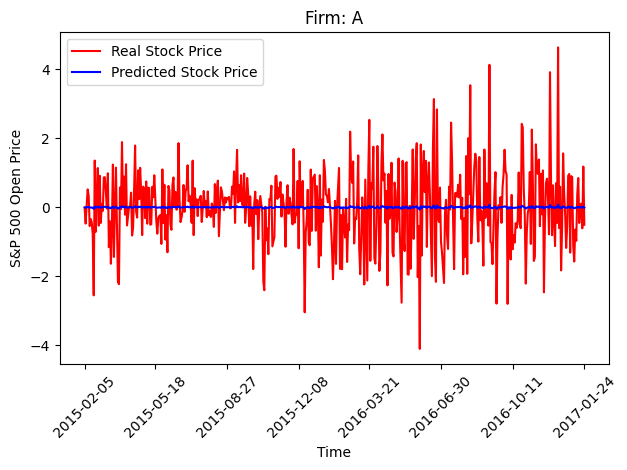

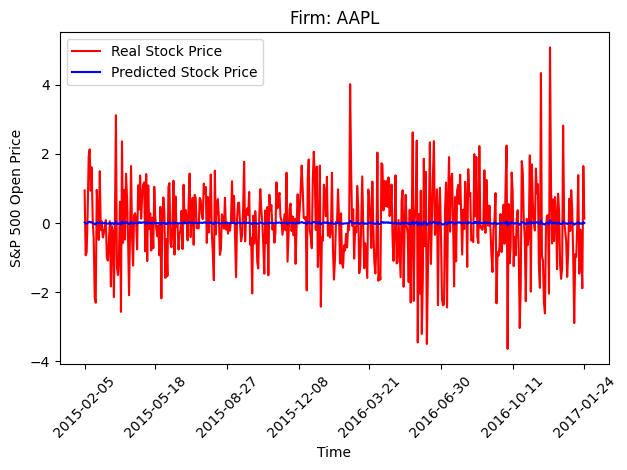

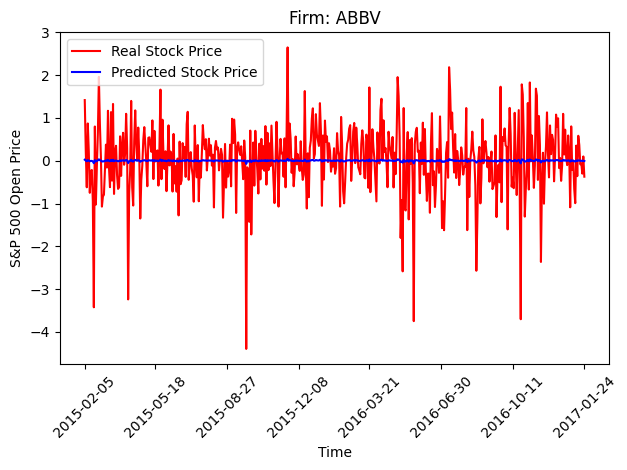

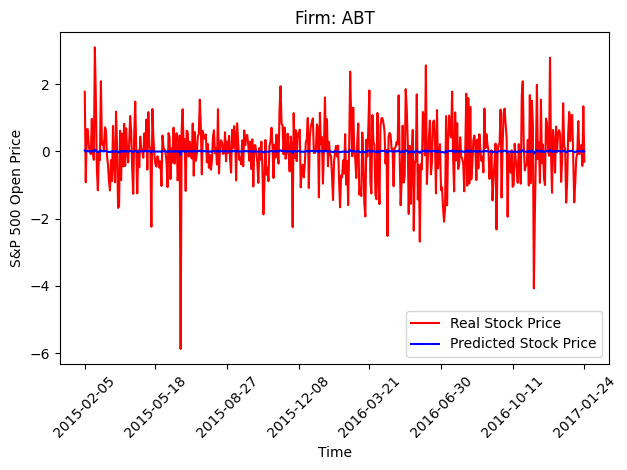

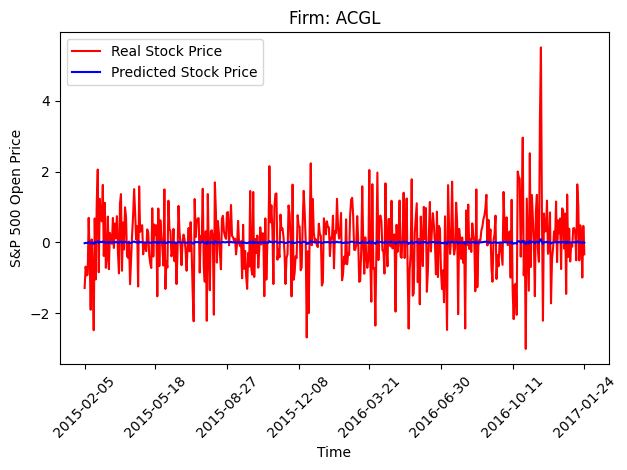

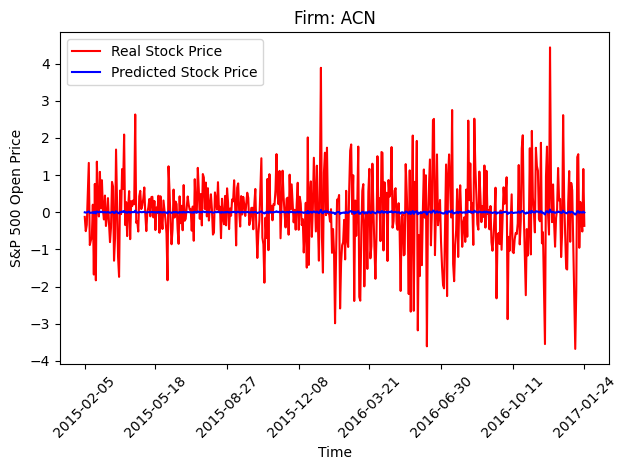

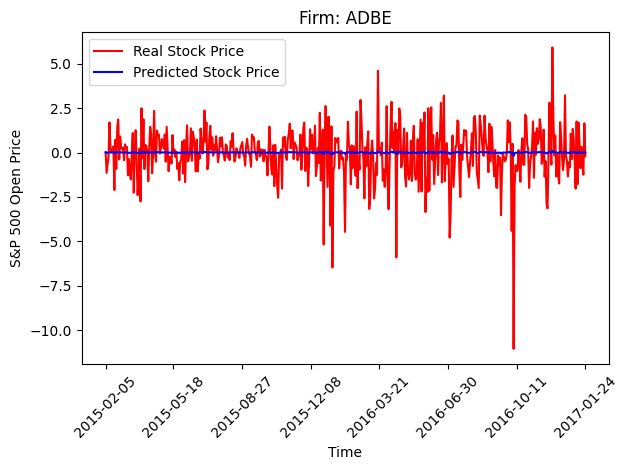

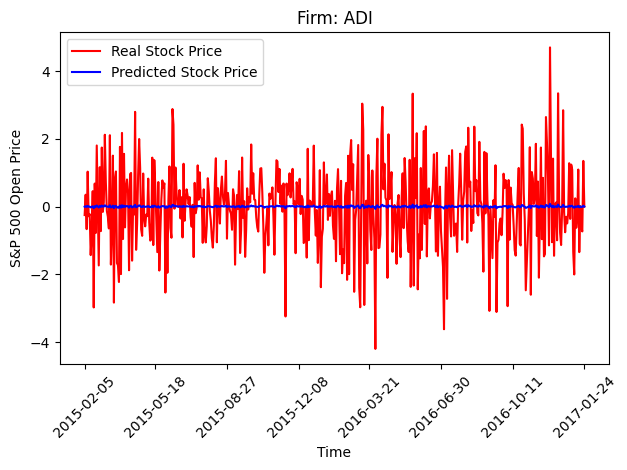

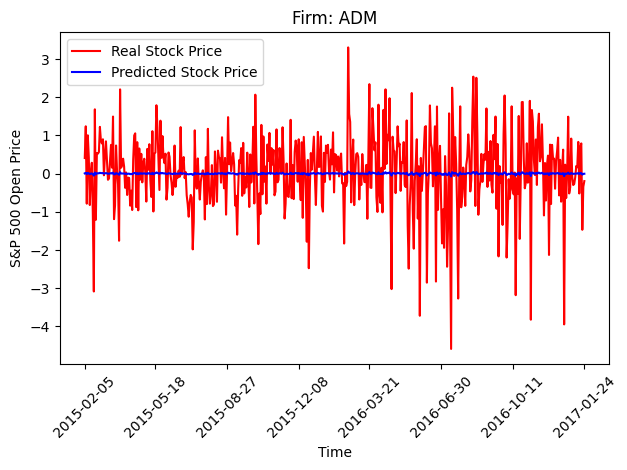

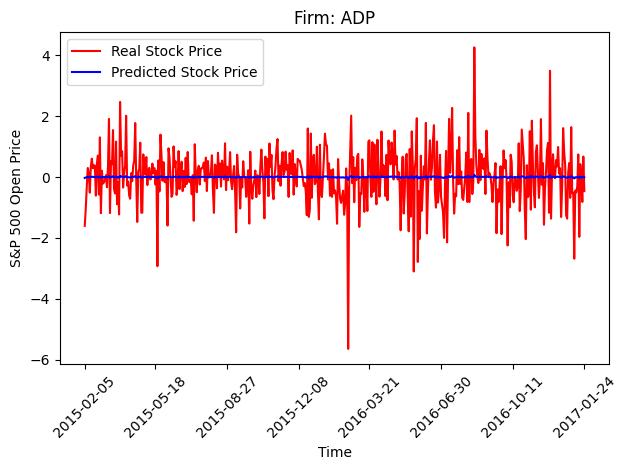

In [17]:
plot_results(y_test, real, open_prices_interp)

In [28]:
metrics_LSTM = compute_metrics(y_test, pred_scaled_LSTM)
print(metrics_LSTM)

{'accuracy': 0.5010212131837307, 'f1': 0.5008807889074507, 'mcc': np.float64(0.0018528134331559636), 'return_ratio': np.float64(-0.42589091696859405), 'sharpe': np.float64(-0.10763073606893407), 'MSE': np.float32(1.5543383)}


# 2. TGC

## Load information for TGC model

In [29]:
# Stock prices
open_prices_interp = pd.read_csv('data_folder/open_prices_interp.csv', index_col=0)
# into numpy
x = open_prices_interp.to_numpy()
tickers_with_data = open_prices_interp.columns

# Load graph data
with open("data_folder/firm_industry.json", "r") as f:
    firm_industry_dict = json.load(f)
A = np.load("data_folder/adjacency_matrix.npy")
adj_matrix = torch.tensor(A, dtype=torch.float32)
batch_size = 32
X_train_TGC, y_train_TGC, X_val_TGC, y_val_TGC, X_test_TGC, y_test_TGC, sc_TGC, train_loader_TGC, val_loader_TGC, test_loader_TGC = create_data(x,
                                                                                                        batch_size =batch_size,
                                                                                                        flatten_data = False, # Should be True for LSTM, False for GTC and GAT
                                                                                                        flatten_time_features=False # Should be True for GAT, False for LSTM and GTC
                                                                                                        )
K = adj_matrix.shape[-1]
x0, y0 = next(iter(train_loader_TGC))
B, L, N, F = x0.shape

torch.Size([984, 8, 460, 5])
torch.Size([984, 460])


## Load TGC models from Best_models/

In [30]:
# Load the 4 saved TGC checkpoints — each was tuned separately and saved with its best params
adj_matrix_dict = {
    'sector':    adj_matrix[:,:,0].unsqueeze(-1),
    'industry':  adj_matrix[:,:,1].unsqueeze(-1),
    'corre':     adj_matrix[:,:,2].unsqueeze(-1),
    'everything':adj_matrix[:,:,:],
}

TGC_dict_adj_matrices = {}

for key in ['sector', 'industry', 'corre', 'everything']:
    checkpoint = torch.load(f'Best_models/best_tgc_{key}.pt', map_location='cpu')

    p              = checkpoint['best_params']
    num_features   = checkpoint['num_features']
    num_relations  = checkpoint['num_relations']

    print(f"\n{key}: {p}  |  val_MSE={checkpoint['best_val_mse']:.6f}")

    model = TGCModel(
        num_features  = num_features,
        emb_dim       = p['emb_dim'],
        gcn_dim       = p['emb_dim'],
        num_relations = num_relations
    )
    for layer in model.head.model:
        if isinstance(layer, nn.Dropout):
            layer.p = p['dropout']

    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    A_loop = adj_matrix_dict[key]
    pred_test_TGC = predict(model, test_loader_TGC, A_loop)

    mse = np.mean((y_test_TGC - pred_test_TGC.numpy())**2, axis=0)
    metrics = compute_metrics(y_test_TGC, pred_test_TGC.numpy())

    TGC_dict_adj_matrices[key] = {
        'model':   model,
        'matrix':  A_loop,
        'pred':    pred_test_TGC,
        'MSE':     mse,
        'metrics': metrics,
        'params':  p,
    }

    print(f"  accuracy={metrics['accuracy']:.4f}  sharpe={metrics['sharpe']:.4f}  return_ratio={metrics['return_ratio']:.4f}")


sector: {'emb_dim': 16, 'lr': 0.007166232931534022, 'dropout': 0.20919280858512043, 'epochs': 20}  |  val_MSE=2.621036
  accuracy=0.4981  sharpe=0.3146  return_ratio=6.7569

industry: {'emb_dim': 32, 'lr': 0.00197433930253344, 'dropout': 0.34171112959787586, 'epochs': 30}  |  val_MSE=2.608470
  accuracy=0.5038  sharpe=-0.1614  return_ratio=-3.5341

corre: {'emb_dim': 16, 'lr': 0.0031172081586338133, 'dropout': 0.13875396894511624, 'epochs': 20}  |  val_MSE=2.610689
  accuracy=0.5063  sharpe=0.1008  return_ratio=1.8195

everything: {'emb_dim': 16, 'lr': 0.00013248066844437172, 'dropout': 0.11854821681281975, 'epochs': 10}  |  val_MSE=2.612432
  accuracy=0.5050  sharpe=-0.1444  return_ratio=-2.9399


## Evaluate TGC Model

In [33]:
MSE_array_average = np.mean((y_test_TGC-np.mean(y_train_TGC,axis=0)[np.newaxis,:])**2, axis=0)

MSE_dict_TGC = {'MSE_array_average': MSE_array_average}
for key in TGC_dict_adj_matrices.keys():
  MSE_dict_TGC[f'MSE_array_{key}'] = TGC_dict_adj_matrices[key]['MSE']

/tmp/ipykernel_480/3790497480.py:591: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(val_list, labels=label_list)


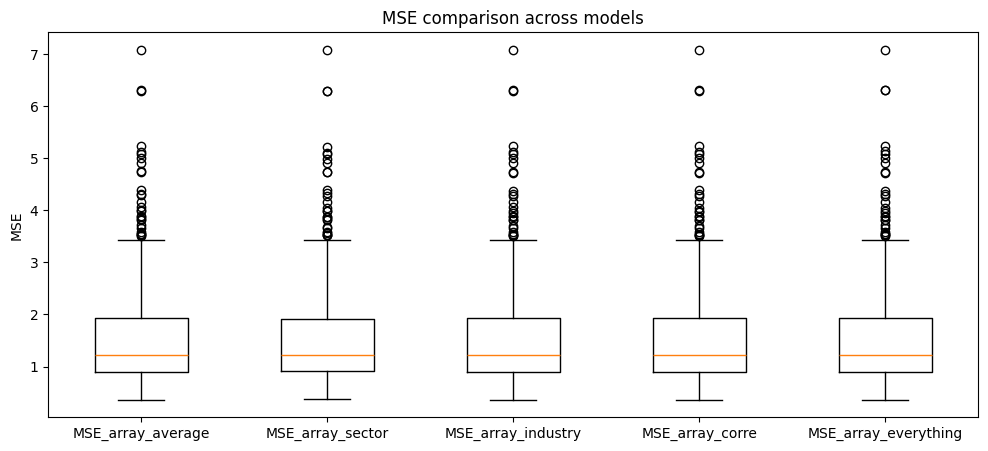

In [34]:
print_box_plots(MSE_dict_TGC)

In [35]:
edge_name_map = {"sector": "Sector", "industry": "Industry", "corre": "Correlation", "everything": "Combined"}

rows = []

# Add LSTM row
rows.append({
    "Edge Type": "LSTM",
    "MSE": metrics_LSTM["MSE"],
    "Accuracy": metrics_LSTM["accuracy"],
    "F1": metrics_LSTM["f1"],
    "MCC": metrics_LSTM["mcc"],
    "Return Ratio": metrics_LSTM["return_ratio"],
    "Sharpe": metrics_LSTM["sharpe"]
})

# Add TGC edge-type rows
for key, result in TGC_dict_adj_matrices.items():
    m = result["metrics"]

    rows.append({
        "Edge Type": edge_name_map.get(key, key),
        "MSE": m["MSE"],
        "Accuracy": m["accuracy"],
        "F1": m["f1"],
        "MCC": m["mcc"],
        "Return Ratio": m["return_ratio"],
        "Sharpe": m["sharpe"]
    })

rq1_table = pd.DataFrame(rows)

# ordering
order = ["LSTM", "Sector", "Industry", "Correlation", "Combined"]
rq1_table["Edge Type"] = pd.Categorical(
    rq1_table["Edge Type"],
    categories=order,
    ordered=True
)
rq1_table = rq1_table.sort_values("Edge Type")

# rounded display version
rq1_table_display = rq1_table.copy()
for col in ["MSE", "Accuracy", "F1", "MCC", "Return Ratio", "Sharpe"]:
    rq1_table_display[col] = rq1_table_display[col].round(4)

# Mark the best one based on each metric
for col in ["MSE", "Accuracy", "F1", "MCC", "Return Ratio", "Sharpe"]:
    if col == "MSE":
        best_idx = rq1_table[col].idxmin()
    else:
        best_idx = rq1_table[col].idxmax()

    rq1_table_display[col] = rq1_table_display[col].astype(str)
    rq1_table_display.loc[best_idx, col] += " *"

display(rq1_table_display)

# save
rq1_table_display.to_csv("rq1_edge_type_table_with_lstm.csv", index=False)

,Edge Type,MSE,Accuracy,F1,MCC,Return Ratio,Sharpe
0,LSTM,1.5543,0.501,0.5009 *,0.0019,-0.4259,-0.1076
1,Sector,1.5538,0.4981,0.3518,0.011 *,6.7569 *,0.3146 *
2,Industry,1.5523,0.5038,0.3439,0.0025,-3.5341,-0.1614
3,Correlation,1.552 *,0.5063 *,0.458,0.0102,1.8195,0.1008
4,Combined,1.5537,0.505,0.384,0.0076,-2.9399,-0.1444


{'accuracy': 0.49812850631136046,
 'f1': 0.3518140778189938,
 'mcc': np.float64(0.011022869228721024),
 'return_ratio': np.float64(6.756864859564037),
 'sharpe': np.float64(0.31461332250198126),
 'MSE': np.float32(1.5538188)}

# 3. GAT

## Load data for GAT

In [40]:
# Stock prices
open_prices_interp = pd.read_csv('data_folder/open_prices_interp.csv', index_col=0)
# into numpy
x = open_prices_interp.to_numpy()
tickers_with_data = open_prices_interp.columns

# Load graph data
with open("data_folder/firm_industry.json", "r") as f:
    firm_industry_dict = json.load(f)
A = np.load("data_folder/adjacency_matrix.npy")
adj_matrix = torch.tensor(A, dtype=torch.float32)

# make training data
batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(x,
                                                                                                        batch_size =batch_size,
                                                                                                        flatten_data = False, # Should be True for LSTM, False for GTC and GAT
                                                                                                        flatten_time_features=True # Should be True for GAT, False for LSTM and GTC
                                                                                                        )

torch.Size([984, 460, 40])
torch.Size([984, 460])


In [41]:
# Best hyperparameters from grid search — 16 trials (see Appendix A.3)
# Best: val_MSE=7.09, test_MSE=2.41, accuracy=0.5009, return_ratio=0.8484, sharpe=0.0698
best_params_GAT = {
    'c_hidden':  16,
    'num_heads':  2,
    'alpha':     0.2,
    'lr':        1e-3
}

## Train GAT model

In [43]:
# GAT model in the current format cannot handle float values and need binary values. So I have set a threshold for correlation
corr = adj_matrix[:, :, 2]
corr_bin = (corr.abs() > 0.5).float()
corr_bin.fill_diagonal_(1.0)

dict_adj_matrices = {'sector':    {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,0].unsqueeze(-1), 'pred':np.empty},
                     'industry':  {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,1].unsqueeze(-1), 'pred':np.empty},
                     'corre':     {'MSE':0, 'model':np.empty, 'matrix':corr_bin.unsqueeze(-1), 'pred':np.empty},
                     'everything':{'MSE':0, 'model':np.empty, 'matrix':torch.stack([adj_matrix[:, :, 0], adj_matrix[:, :, 1], corr_bin], dim=-1), 'pred':np.empty}
                     }

for key in dict_adj_matrices.keys():
  print(f'Doing model: {key}')
  A_loop = dict_adj_matrices[key]['matrix']
  K_num_relations = A_loop.shape[-1] # This will be 1 for single relations, and 3 for 'everything'

  model_GAT = GAT(c_in=40, c_hidden=best_params_GAT['c_hidden'], num_relations= K_num_relations, c_out=1, num_heads=best_params_GAT['num_heads'], alpha=best_params_GAT['alpha'])
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model_GAT.parameters(), lr=best_params_GAT['lr'])

  num_epochs = 75 # My general observation is that it takes many more epochs to train this model
  train_losses = []
  val_losses = []

  for epoch in range(num_epochs):
      train_loss = train_one_epoch_GAT(model_GAT, train_loader, A_loop, optimizer, criterion)
      val_loss = evaluate_GAT(model_GAT, val_loader, A_loop, criterion)
      print(f"Epoch {epoch+1:03d} | train loss {train_loss:.6f} | val loss {val_loss:.6f}")

  dict_adj_matrices[key]['model'] = model_GAT
  pred_test_GAT = predict_GAT(model_GAT, test_loader, A_loop)

  dict_adj_matrices[key]['pred'] = pred_test_GAT

  mse_result = np.mean((y_test-pred_test_GAT.numpy())**2,axis=0)
  dict_adj_matrices[key]['MSE'] = mse_result

  # Compute and store metrics
  current_metrics = compute_metrics(y_test, pred_test_GAT.numpy())
  dict_adj_matrices[key]['metrics'] = current_metrics


Doing model: sector
Epoch 001 | train loss 2.737141 | val loss 5.724059
Epoch 002 | train loss 1.808562 | val loss 4.468986
Epoch 003 | train loss 1.511314 | val loss 3.909580
Epoch 004 | train loss 1.360627 | val loss 3.617433
Epoch 005 | train loss 1.274763 | val loss 3.421621
Epoch 006 | train loss 1.214913 | val loss 3.289416
Epoch 007 | train loss 1.174556 | val loss 3.198249
Epoch 008 | train loss 1.146530 | val loss 3.124062
Epoch 009 | train loss 1.124741 | val loss 3.075805
Epoch 010 | train loss 1.110108 | val loss 3.052681
Epoch 011 | train loss 1.097615 | val loss 2.993998
Epoch 012 | train loss 1.085973 | val loss 2.952247
Epoch 013 | train loss 1.075476 | val loss 2.930909
Epoch 014 | train loss 1.069118 | val loss 2.912400
Epoch 015 | train loss 1.063299 | val loss 2.897883
Epoch 016 | train loss 1.057614 | val loss 2.874771
Epoch 017 | train loss 1.052817 | val loss 2.854949
Epoch 018 | train loss 1.051379 | val loss 2.845646
Epoch 019 | train loss 1.048520 | val loss 2

In [44]:
MSE_dict_GAT = {}
for key in dict_adj_matrices.keys():
    MSE_dict_GAT[key] = dict_adj_matrices[key]['MSE']

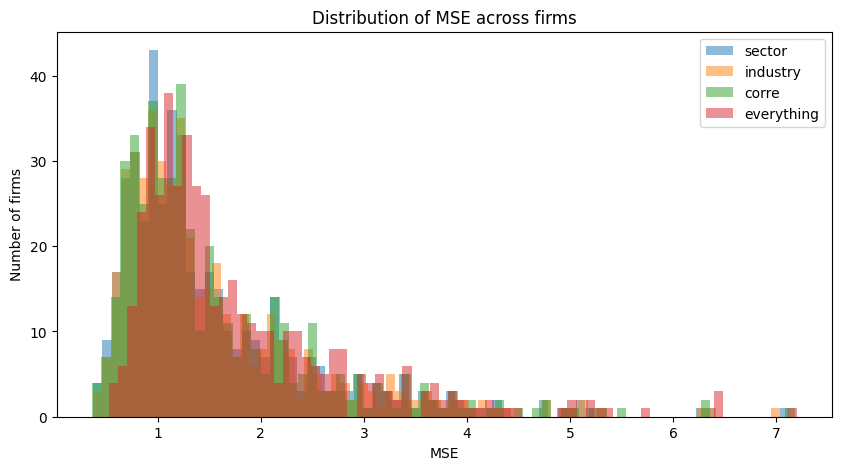

In [45]:
# plot results that compares GAT
plt.figure(figsize=(10,5))

for key, val in MSE_dict_GAT.items():
  plt.hist(val, bins=75, alpha=0.5, label=f'{key}')

plt.legend()
plt.title("Distribution of MSE across firms")
plt.xlabel("MSE")
plt.ylabel("Number of firms")
plt.show()

/tmp/ipykernel_480/3790497480.py:591: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(val_list, labels=label_list)


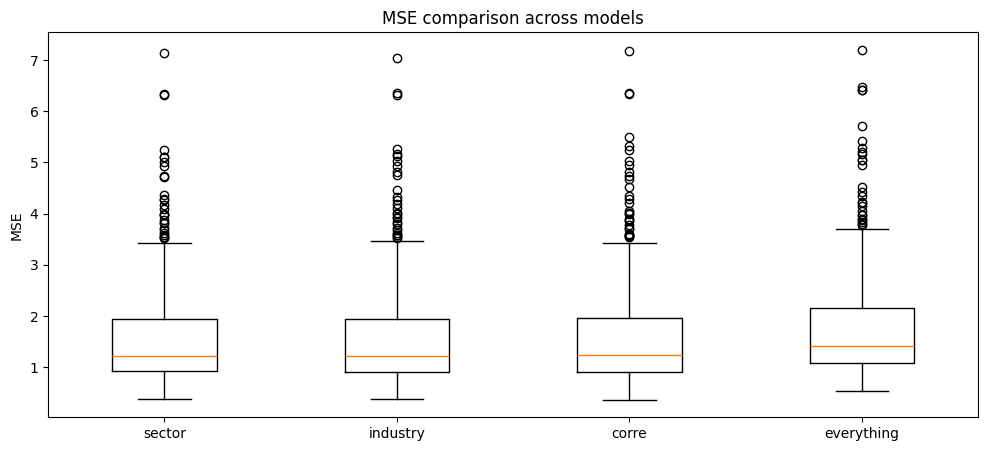

In [46]:
print_box_plots(MSE_dict_GAT)

# 4. GAT + RotatE

## Load data for GAT+RotatE

In [47]:
# Stock prices
open_prices_interp = pd.read_csv('data_folder/open_prices_interp.csv', index_col=0)
# into numpy
x = open_prices_interp.to_numpy()
tickers_with_data = open_prices_interp.columns

# Load graph data
with open("data_folder/firm_industry.json", "r") as f:
    firm_industry_dict = json.load(f)
A = np.load("data_folder/adjacency_matrix.npy")
adj_matrix = torch.tensor(A, dtype=torch.float32)

# make training data
batch_size =32
X_train, y_train, X_val, y_val, X_test, y_test, sc, train_loader, val_loader, test_loader = create_data(x,
                                                                                                        batch_size =batch_size,
                                                                                                        flatten_data = False, # Should be True for LSTM, False for GTC and GAT
                                                                                                        flatten_time_features=True # Should be True for GAT, False for LSTM and GTC
                                                                                                        )

torch.Size([984, 460, 40])
torch.Size([984, 460])


In [48]:
# Best hyperparameters from grid search — 16 trials (see Appendix A.4)
# Best GAT_RotatE: val_MSE=0.0842, test_MSE=1.5816 (lambda_rotate=0.1 beat lambda=0)
best_params_RotatE = {
    'c_hidden':       32,
    'emb_dim':        16,
    'num_heads':       2,
    'lr':            1e-3,
    'lambda_rotate': 0.1,
    'corr_threshold': 0.5
}

## Train GAT+RotatE model

In [49]:
def build_edges(adj_matrix):
    edge_index_list = []
    edge_type_list = []

    R = adj_matrix.shape[-1]
    for r in range(R):
        adj_r = adj_matrix[:, :, r]
        edges = (adj_r > 0).nonzero(as_tuple=False)

        # remove self loops
        edges = edges[edges[:, 0] != edges[:, 1]]

        edge_index_list.append(edges)
        edge_type_list.append(
            torch.full((edges.shape[0],), r, dtype=torch.long)
        )

    edge_index = torch.cat(edge_index_list, dim=0)
    edge_type = torch.cat(edge_type_list, dim=0)
    return edge_index, edge_type

In [51]:
import torch.nn.functional as F
# GAT model in the current format cannot handle float values and need binary values. So I have set a threshold for correlation
corr = adj_matrix[:, :, 2]
corr_bin = (corr.abs() > best_params_RotatE['corr_threshold']).float()
corr_bin.fill_diagonal_(1.0)

dict_adj_matrices_gat_rotate = {'sector':    {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,0].unsqueeze(-1), 'pred':np.empty},
                                'industry':  {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,1].unsqueeze(-1), 'pred':np.empty},
                                'corre':     {'MSE':0, 'model':np.empty, 'matrix':corr_bin.unsqueeze(-1), 'pred':np.empty},
                                'everything':{'MSE':0, 'model':np.empty, 'matrix':torch.stack([adj_matrix[:, :, 0], adj_matrix[:, :, 1], corr_bin], dim=-1), 'pred':np.empty}
                                }

for key in dict_adj_matrices_gat_rotate.keys():
  print(f'Doing model: {key}')
  A_loop = dict_adj_matrices_gat_rotate[key]['matrix']
  edge_index, edge_type = build_edges(A_loop)
  K_num_relations = A_loop.shape[-1] # This will be 1 for single relations, and 3 for 'everything'

  model_GAT_RotatE = GAT_RotatE(c_in=40, c_hidden=best_params_RotatE['c_hidden'], emb_dim=best_params_RotatE['emb_dim'], num_relations=K_num_relations,num_heads=best_params_RotatE['num_heads'])
  optimizer = optim.Adam(model_GAT_RotatE.parameters(), lr=best_params_RotatE['lr'])

  num_epochs = 10 # While GAT needs many, this one is super quick at finding the right optimum, but super heavy to compute
  train_losses = []
  val_losses = []

  for epoch in range(num_epochs):
      train_loss = train_one_epoch_GAT_RotatE(model_GAT_RotatE, train_loader, A_loop, edge_index, edge_type, optimizer, lambda_rotate=best_params_RotatE['lambda_rotate'])
      val_loss = evaluate_GAT_RotatE(model_GAT_RotatE, val_loader, A_loop) # BTW it uses a different kind of loss function than MSE, so can't compare this number with the others
      print(f"Epoch {epoch+1:03d} | train loss {train_loss:.6f} | val loss {val_loss:.6f}")

  dict_adj_matrices_gat_rotate[key]['model'] = model_GAT_RotatE
  pred_test_GAT_RotatE = predict_GAT_RotatE(model_GAT_RotatE, test_loader, A_loop)

  dict_adj_matrices_gat_rotate[key]['pred'] = pred_test_GAT_RotatE

  mse_result = np.mean((y_test-pred_test_GAT_RotatE.numpy())**2,axis=0)
  dict_adj_matrices_gat_rotate[key]['MSE'] = mse_result

  # Compute and store metrics
  current_metrics = compute_metrics(y_test, pred_test_GAT_RotatE.numpy())
  dict_adj_matrices_gat_rotate[key]['metrics'] = current_metrics


Doing model: sector
Epoch 001 | train loss 3.167078 | val loss 0.088908
Epoch 002 | train loss 2.041917 | val loss 0.086080
Epoch 003 | train loss 1.656936 | val loss 0.085150
Epoch 004 | train loss 1.467128 | val loss 0.084470
Epoch 005 | train loss 1.358027 | val loss 0.084136
Epoch 006 | train loss 1.293578 | val loss 0.083933
Epoch 007 | train loss 1.249101 | val loss 0.083684
Epoch 008 | train loss 1.217519 | val loss 0.083553
Epoch 009 | train loss 1.196701 | val loss 0.083587
Epoch 010 | train loss 1.181849 | val loss 0.083493
Doing model: industry
Epoch 001 | train loss 2.595477 | val loss 0.090258
Epoch 002 | train loss 1.477113 | val loss 0.086521
Epoch 003 | train loss 1.299145 | val loss 0.086010
Epoch 004 | train loss 1.240316 | val loss 0.085762
Epoch 005 | train loss 1.207161 | val loss 0.085309
Epoch 006 | train loss 1.187577 | val loss 0.085442
Epoch 007 | train loss 1.171923 | val loss 0.085295
Epoch 008 | train loss 1.162115 | val loss 0.085178
Epoch 009 | train loss

In [52]:
MSE_dict_RotatE = {}
for key in dict_adj_matrices.keys():
    MSE_dict_RotatE[key] = dict_adj_matrices[key]['MSE']

/tmp/ipykernel_480/3790497480.py:591: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(val_list, labels=label_list)


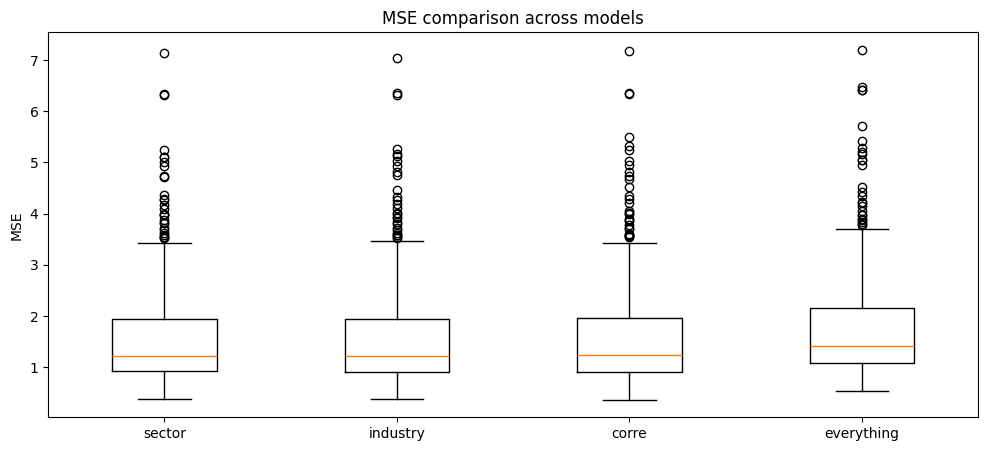

In [53]:
print_box_plots(MSE_dict_RotatE)

# Compare models

In [ ]:
dict_adj_matrices_gat = dict_adj_matrices

edge_name_map = {
    "sector": "Sector",
    "industry": "Industry",
    "corre": "Correlation",
    "everything": "Combined"
}

edge_order = ["sector", "industry", "corre", "everything"]

rows = []

# LSTM has no graph edge type
rows.append({
    "Model": "LSTM",
    "Edge Type": "None",
    **metrics_LSTM
})

# TGC, GAT, GAT+RotatE for all edge types
model_dicts = {
    "TGC": TGC_dict_adj_matrices,
    "GAT": dict_adj_matrices_gat,
    "GAT+RotatE": dict_adj_matrices_gat_rotate
}

for model_name, results_dict in model_dicts.items():
    for edge_key in edge_order:
        m = results_dict[edge_key]["metrics"]

        rows.append({
            "Model": model_name,
            "Edge Type": edge_name_map[edge_key],
            **m
        })

rq2_table = pd.DataFrame(rows)

# rename columns
rq2_table = rq2_table.rename(columns={
    "accuracy": "Accuracy",
    "f1": "F1",
    "mcc": "MCC",
    "return_ratio": "Return Ratio",
    "sharpe": "Sharpe"
})

# reorder columns
rq2_table = rq2_table[
    ["Model", "Edge Type", "Sharpe", "Return Ratio", "MSE", "Accuracy", "F1", "MCC"]
]

# round display version
rq2_display = rq2_table.copy()
for col in ["Sharpe", "Return Ratio", "MSE", "Accuracy", "F1", "MCC"]:
    rq2_display[col] = rq2_display[col].round(4)

# add stars for best values
for col in ["Sharpe", "Return Ratio", "MSE", "Accuracy", "F1", "MCC"]:
    if col == "MSE":
        best_idx = rq2_table[col].idxmin()
    else:
        best_idx = rq2_table[col].idxmax()

    rq2_display[col] = rq2_display[col].astype(str)
    rq2_display.loc[best_idx, col] += " *"

display(rq2_display)

# save
rq2_display.to_csv("rq2_model_comparison_all_edges.csv", index=False)

,Model,Edge Type,Sharpe,Return Ratio,MSE,Accuracy,F1,MCC
0,LSTM,None,-0.1076,-0.4259,1.5543,0.501,0.5009,0.0019
1,TGC,Sector,0.3146,6.7569,1.5538,0.4981,0.3518,0.011
2,TGC,Industry,-0.1614,-3.5341,1.5523,0.5038,0.3439,0.0025
3,TGC,Correlation,0.1008,1.8195,1.552,0.5063,0.458,0.0102
4,TGC,Combined,-0.1444,-2.9399,1.5537,0.505,0.384,0.0076
5,GAT,Sector,1.1716,13.8596,1.5675,0.5076,0.5075,0.0154
6,GAT,Industry,1.0696,15.2725,1.5707,0.5108,0.5077,0.0208
7,GAT,Correlation,-0.3645,-6.4315,1.5839,0.4929,0.4929,-0.014
8,GAT,Combined,1.4146,15.0534,1.773,0.5075,0.5072,0.0155
9,GAT+RotatE,Sector,0.8795,11.3899,1.5538,0.5073,0.5011,0.0167


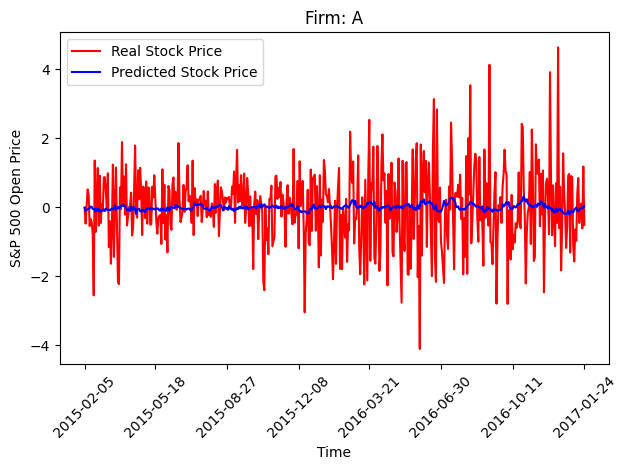

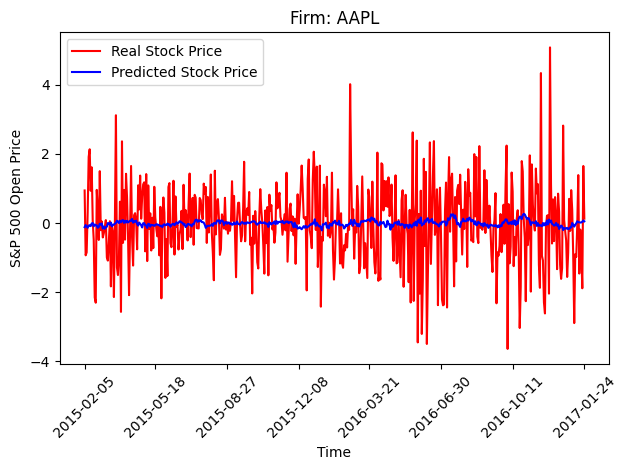

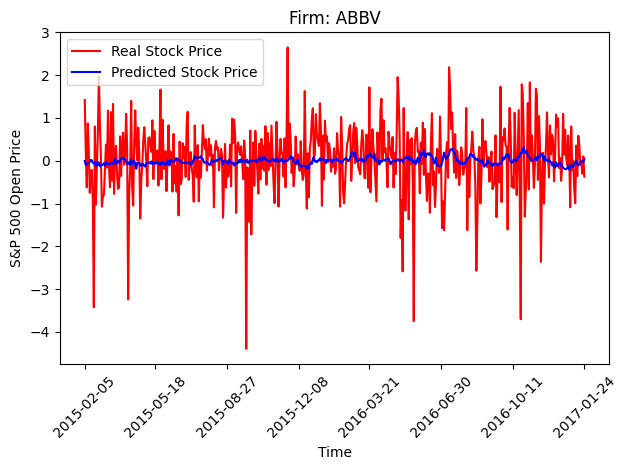

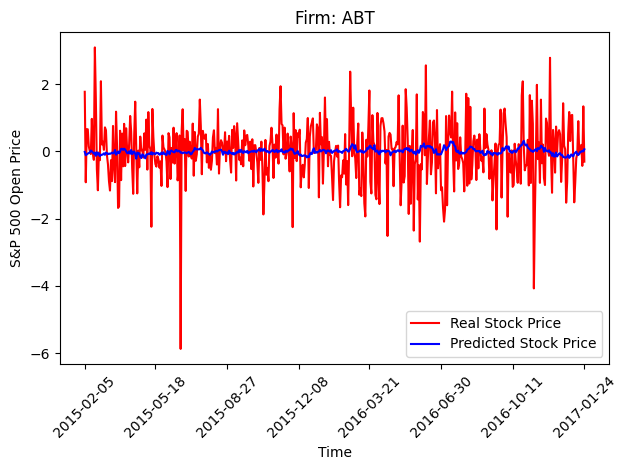

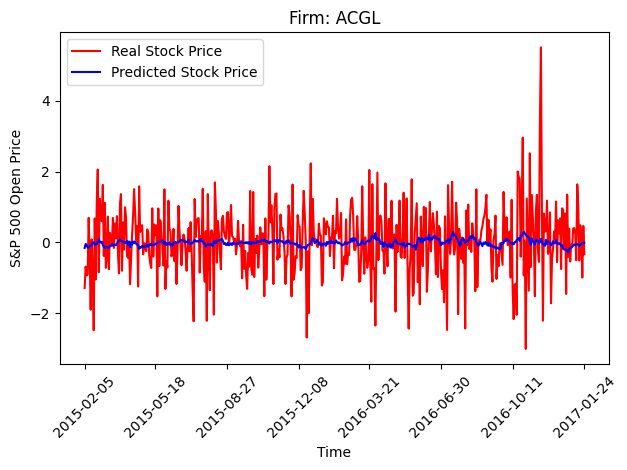

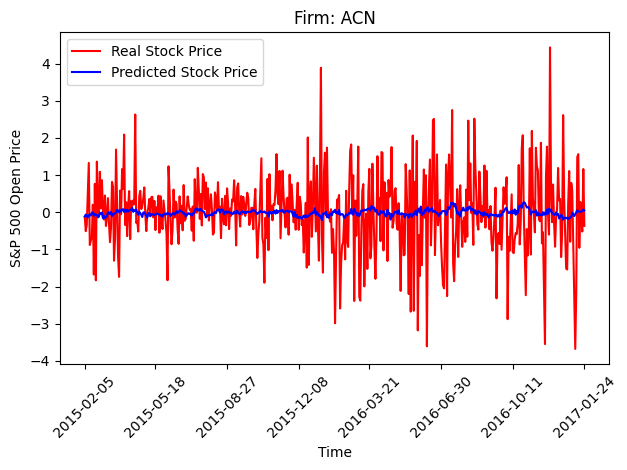

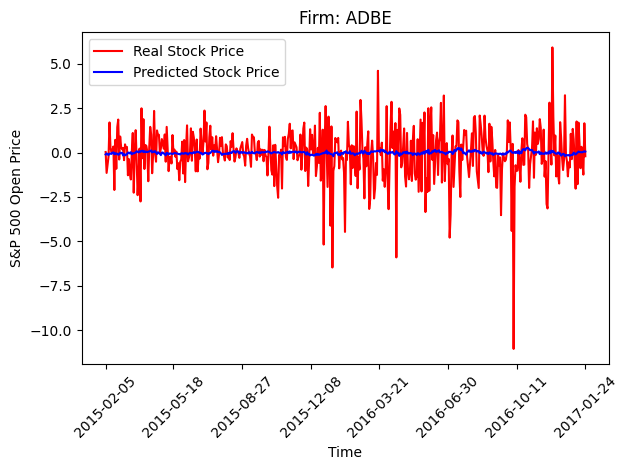

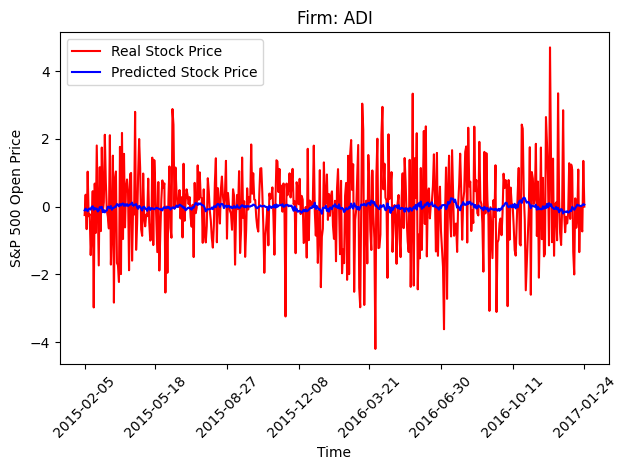

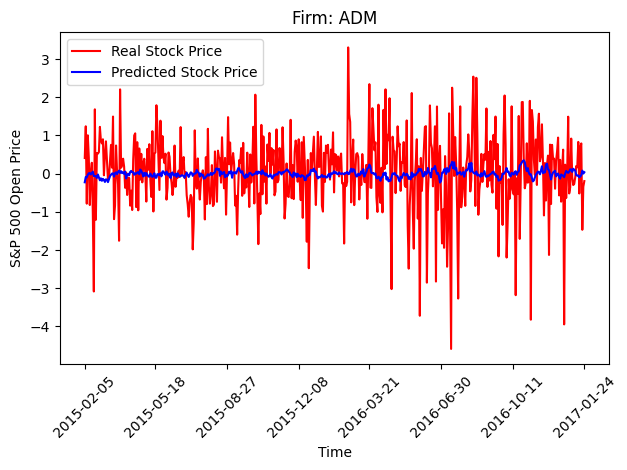

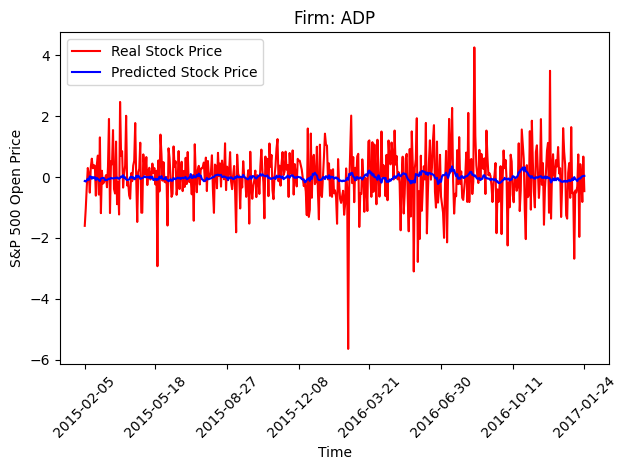

In [66]:
plot_results(y_test, dict_adj_matrices_gat_rotate['industry']['pred'], open_prices_interp)

/tmp/ipykernel_480/2831425372.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(selected.values(), labels=selected.keys())


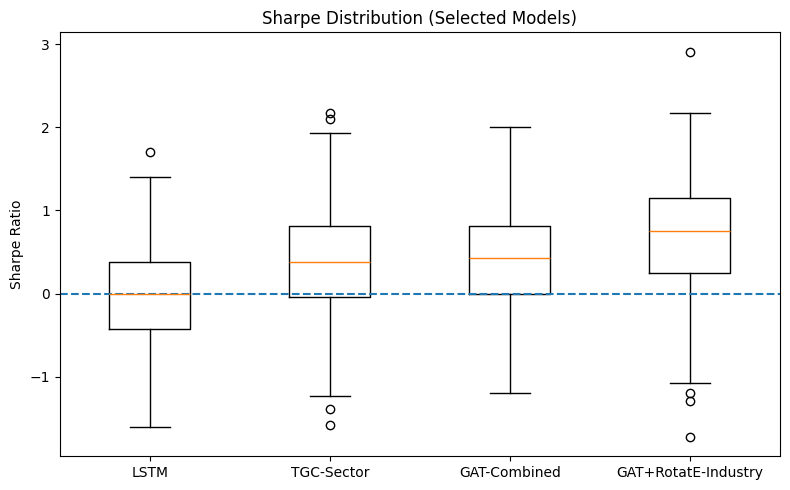

In [ ]:
def sharpe_per_firm(y_true, y_pred):
    y_pred_dir = (y_pred > 0).astype(int)
    trade_sign = np.where(y_pred_dir == 1, 1, -1)

    strategy_returns = y_true * trade_sign  # [T, N]

    sharpe_list = []
    for i in range(strategy_returns.shape[1]):
        r = strategy_returns[:, i]

        std = r.std()
        if std > 0:
            sharpe = (r.mean() / std) * np.sqrt(252)
        else:
            sharpe = 0.0

        sharpe_list.append(sharpe)

    return np.array(sharpe_list)  

sharpe_dict = {}

# LSTM
sharpe_dict["LSTM"] = sharpe_per_firm(y_test, pred_scaled_LSTM)

# TGC
for key in ["sector", "industry", "corre", "everything"]:
    sharpe_dict[f"TGC-{key}"] = sharpe_per_firm(
        y_test_TGC,
        dict_adj_matrices[key]["pred"].numpy()
    )

# GAT
for key in ["sector", "industry", "corre", "everything"]:
    sharpe_dict[f"GAT-{key}"] = sharpe_per_firm(
        y_test_TGC,
        dict_adj_matrices_gat[key]["pred"].numpy()
    )

# GAT+RotatE
for key in ["sector", "industry", "corre", "everything"]:
    sharpe_dict[f"GAT+RotatE-{key}"] = sharpe_per_firm(
        y_test_TGC,
        dict_adj_matrices_gat_rotate[key]["pred"].numpy()
    )

selected = {
    "LSTM": sharpe_dict["LSTM"],
    "TGC-Sector": sharpe_dict["TGC-sector"],
    "GAT-Combined": sharpe_dict["GAT-everything"],
    "GAT+RotatE-Industry": sharpe_dict["GAT+RotatE-industry"],
}

plt.figure(figsize=(8,5))
plt.boxplot(selected.values(), labels=selected.keys())
plt.axhline(0, linestyle="--")
plt.title("Sharpe Distribution (Selected Models)")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig("rq2_boxplot_best.png", dpi=300)
plt.show()

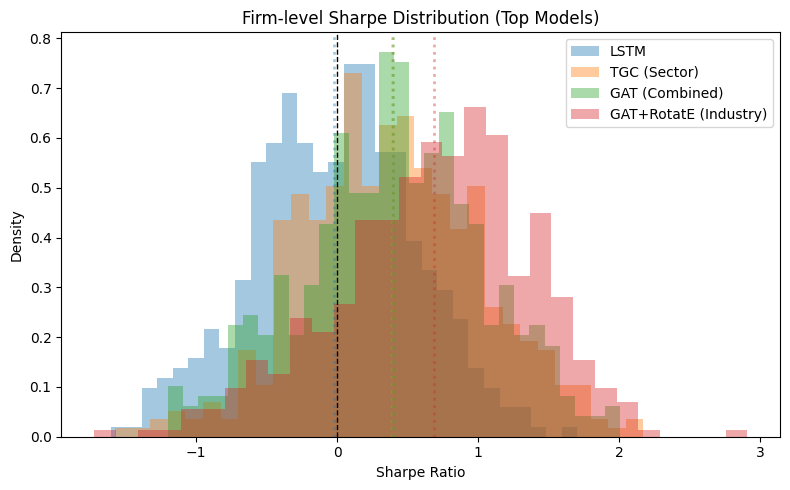

In [84]:
plt.figure(figsize=(8,5))

bins = 30

# Plot histograms and store colors
h1 = plt.hist(
    sharpe_dict["LSTM"],
    bins=bins,
    alpha=0.4,
    density=True,
    label="LSTM"
)

h2 = plt.hist(
    sharpe_dict["TGC-sector"],
    bins=bins,
    alpha=0.4,
    density=True,
    label="TGC (Sector)"
)

h3 = plt.hist(
    sharpe_dict["GAT-everything"],
    bins=bins,
    alpha=0.4,
    density=True,
    label="GAT (Combined)"
)

h4 = plt.hist(
    sharpe_dict["GAT+RotatE-industry"],
    bins=bins,
    alpha=0.4,
    density=True,
    label="GAT+RotatE (Industry)"
)

# Extract colors (from patches)
colors = [
    h1[2][0].get_facecolor(),
    h2[2][0].get_facecolor(),
    h3[2][0].get_facecolor(),
    h4[2][0].get_facecolor(),
]

# Mean lines with matching colors
for (data, color) in zip([
    sharpe_dict["LSTM"],
    sharpe_dict["TGC-sector"],
    sharpe_dict["GAT-everything"],
    sharpe_dict["GAT+RotatE-industry"]
], colors):
    plt.axvline(data.mean(), linestyle=":", linewidth=2, color=color)

# zero line
plt.axvline(0, linestyle="--", linewidth=1, color="black")

plt.title("Firm-level Sharpe Distribution (Top Models)")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.savefig("rq2_sharpe_overlap_hist.png", dpi=300)
plt.show()

# 2022 Stress Period Analysis

The following leverages the four models to analyse the specific year of 2022 to identify whether the graph-augmented models outperform the LSTM model during that year's market stress period when it was a "bear" market, in which several stock indices declined during most of the year.

In [ ]:
# RQ3 — 2022 Stress Period Analysis

# load all predictions from saved files
pred_scaled_LSTM = np.load('Best_models/pred_LSTM.npy')
y_test = np.load('Best_models/y_test.npy')
pred_TGC = np.load('Best_models/pred_TGC_everything.npy')
pred_GAT = np.load('Best_models/pred_GAT_everything.npy')
pred_RotatE = np.load('Best_models/pred_GAT_RotatE_everything.npy')

# recover test set dates
open_prices_interp.index = pd.to_datetime(open_prices_interp.index)
dates = open_prices_interp.index[29:]
dates_seq = dates[8:]
n = len(dates_seq)
val_end = n // 2 + n // 4
test_dates = dates_seq[val_end:]

# find 2022 indices
idx_2022 = [i for i, d in enumerate(test_dates) if d.year == 2022]
print(f"2022 days in test set: {len(idx_2022)}")

# slice to 2022
y_2022 = y_test[idx_2022]
pred_LSTM_2022   = pred_scaled_LSTM[idx_2022]
pred_TGC_2022    = pred_TGC[idx_2022]
pred_GAT_2022    = pred_GAT[idx_2022]
pred_RotatE_2022 = pred_RotatE[idx_2022]

# compute metrics
rows = []
for name, pred in [('LSTM', pred_LSTM_2022), ('TGC', pred_TGC_2022),
                    ('GAT', pred_GAT_2022), ('GAT+RotatE', pred_RotatE_2022)]:
    m = compute_metrics(y_2022, pred)
    rows.append({'model': name, **m})

df_2022 = pd.DataFrame(rows).set_index('model')
print("\n2022 Stress Period Metrics:")   #yes, the graph-augmented models (GAT, GAT+RotatE) do outperform LSTM during the 2022 stress period, especially on financial metrics
display(df_2022)

2022 days in test set: 251

2022 Stress Period Metrics:


,accuracy,f1,mcc,return_ratio,sharpe,MSE
model,,,,,,
LSTM,0.501135,0.500841,0.003967,-0.630068,-0.231262,1.966647
TGC,0.490967,0.373327,0.006122,-10.612655,-0.843762,1.966909
GAT,0.504469,0.503888,0.007894,5.169787,0.908103,2.321207
GAT+RotatE,0.510514,0.510513,0.021498,5.463871,0.758592,1.978539


---
# Appendix — Hyperparameter Tuning Code

> These cells contain the full tuning searches that produced the `best_params_*` dicts used in the main sections above. They do not need to be re-run to execute the main pipeline.

## A.1  LSTM Tuning (Optuna, 30 trials)

In [ ]:
SEARCH_N_TRIALS = 30

best_model_state_global = None
best_loss_global = float("inf")

def objective(trial):
    global best_model_state_global, best_loss_global

    hidden_units = trial.suggest_int("lstm_units", 64, 256, step=64)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 5e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128, 256])
    epochs = trial.suggest_int("epochs", 15, 40)
    patience = trial.suggest_int("patience", 5, 10)

    model = LSTMRegressor(
        input_size=X_train.shape[2],
        hidden_units=hidden_units,
        output_size=y_train.shape[1],
        dropout_rate=dropout_rate
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float("inf")
    best_state_dict = None
    patience_counter = 0
    trial_start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch_LSTM(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate_LSTM(model, val_loader, criterion)

        print(
            f"Trial {trial.number + 1}/{SEARCH_N_TRIALS} | "
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}"
        )

        trial.report(val_loss, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
            trial.set_user_attr("best_val_acc", val_acc)
            if val_loss < best_loss_global:
                best_loss_global = val_loss
                best_model_state_global = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    trial.set_user_attr("training_time_s", time.time() - trial_start_time)
    return best_val_loss

## Fine tune model

In [ ]:
# run trials
best_overall_loss, best_config, best_model_final, best_history_final = 100.0, {}, None, None

results_log = []
search_start_time = time.time()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=SEARCH_N_TRIALS)

for trial in study.trials:
    if trial.value is None:
        continue

    results_log.append({
        'config_id': trial.number + 1,
        'params': str(trial.params),
        'val_loss': trial.value,
        'training_time_s': trial.user_attrs.get('training_time_s', np.nan)
    })

results_df = pd.DataFrame(results_log).sort_values(by='val_loss', ascending=True)
search_end_time = time.time()
total_duration = search_end_time - search_start_time

best_params = study.best_trial.params
best_config = dict(best_params)
best_overall_loss = study.best_trial.value

print("\n" + "=" * 60)
print(f"Optuna Search Complete in {total_duration:.2f} seconds.")
print(f"Best Configuration: {best_config} | Best Val loss: {best_overall_loss:.4f}")

print("\n--- Detailed Hyperparameter Search Results ---")
print(results_df)

print("\nBest trial:")
print("  Value:", study.best_trial.value)
print("  Params:")
for k, v in study.best_trial.params.items():
    print(f"    {k}: {v}")

## Save best model

In [ ]:
output_size = y_train.shape[1]
input_size = X_train.shape[2]

model_LSTM = LSTMRegressor(
    input_size=input_size,
    hidden_units=best_params['lstm_units'],
    output_size=output_size,
    dropout_rate=best_params['dropout_rate']
)
model_LSTM.load_state_dict(best_model_state_global)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_LSTM.parameters(), lr=best_params['learning_rate'])
MODEL_SAVE_PATH = 'best_lstm_model_graphtheory.pt'

torch.save({
    'model_state_dict': model_LSTM.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hyperparameters': best_params,
}, MODEL_SAVE_PATH)

In [ ]:
from google.colab import files
files.download(MODEL_SAVE_PATH)

In [ ]:
test_loss_LSTM, _ = evaluate_LSTM(model_LSTM, test_loader, criterion)
print("Test loss:", test_loss_LSTM)

## A.2  TGC Tuning (Optuna, 5 trials per graph type)

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial, adj_key, metric_name):
    """
    trial:       Optuna gives this automatically — it's how you ask for hyperparameter suggestions
    adj_key:     which graph to use — 'sector', 'industry', 'corre', or 'everything'
    metric_name: which metric to optimise for — 'accuracy', 'f1', 'mcc', 'return_ratio', 'sharpe'
    """

    # Optuna suggests hyperparameter values for this trial
    # Each suggest_ call says: "pick me a value from this range"
    # Optuna gets smarter about which values to pick after each trial

    emb_dim  = trial.suggest_categorical('emb_dim', [16, 32, 64, 128])
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)  # log=True = search on log scale, better for lr
    dropout  = trial.suggest_float('dropout', 0.1, 0.5)
    epochs   = trial.suggest_categorical('epochs', [10, 20, 30])

    # Build the TGC model with those hyperparameters
    A_loop = dict_adj_matrices[adj_key]['matrix']
    K_num_relations = A_loop.shape[-1]

    model = TGCModel(
        num_features  = F,
        emb_dim       = emb_dim,
        gcn_dim       = emb_dim,
        num_relations = K_num_relations
    )

    # Swap the fixed dropout in Header for the trial's dropout value
    # (overrides the hardcoded 0.2 in Nat's Header class)
    for layer in model.head.model:
        if isinstance(layer, nn.Dropout):
            layer.p = dropout

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train for the chosen number of epochs
    for epoch in range(epochs):
        train_one_epoch(model, train_loader_TGC, A_loop, optimizer, criterion)

    # Get predictions on VALIDATION set (not test — never peek at test during tuning)
    val_preds = predict(model, val_loader_TGC, A_loop).numpy()  # shape [T_val, N]

    # y_val is the true returns for the validation period
    metrics = compute_metrics(y_val_TGC, val_preds)

    # Return the metric Optuna should maximise
    return metrics[metric_name]

## Fine tune and save best model

In [ ]:
N_TRIALS = 5  # change to 50 for real results

# Define F - number of features. This was missing and caused a TypeError in the LSTM layer.
# Based on X_train.shape which is (984, 8, 460, 5), the number of features is 5.
F = X_train_TGC.shape[-1] # X_train is available in kernel state

dict_adj_matrices_tune = {'sector':    {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,0].unsqueeze(-1), 'pred':np.empty},
                     'industry':  {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,1].unsqueeze(-1), 'pred':np.empty},
                     'corre':     {'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,2].unsqueeze(-1), 'pred':np.empty},
                     'everything':{'MSE':0, 'model':np.empty, 'matrix':adj_matrix[:,:,:],               'pred':np.empty} }

results = {}

for metric_name in ['MSE']: # I only care about one metric, which is MSE. Only optimize over 1 metric
    results[metric_name] = {}

    for adj_key in ['sector', 'industry', 'corre', 'everything']:
        print(f"\nOptimising {metric_name} on {adj_key} graph...")

        study = optuna.create_study(direction='maximize')
        study.optimize(lambda trial: objective(trial, adj_key, metric_name), n_trials=N_TRIALS)

        results[metric_name][adj_key] = {
            'best_value':  round(study.best_value, 4),
            'best_params': study.best_params
        }
        print(f"  Best {metric_name}: {study.best_value:.4f} | params: {study.best_params}")

final_models = {}
final_preds  = {}
saved_model_paths = {}

for metric_name in results:
    final_models[metric_name] = {}
    final_preds[metric_name]  = {}
    saved_model_paths[metric_name] = {}

    for adj_key in ['sector', 'industry', 'corre', 'everything']:
        print(f"\nRetraining best {metric_name} / {adj_key} model...")

        p      = results[metric_name][adj_key]['best_params']
        A_loop = dict_adj_matrices_tune[adj_key]['matrix']
        K_num_relations = A_loop.shape[-1]

        model = TGCModel(
            num_features  = F,
            emb_dim       = p['emb_dim'],
            gcn_dim       = p['emb_dim'],
            num_relations = K_num_relations
        )

        for layer in model.head.model:
            if isinstance(layer, nn.Dropout):
                layer.p = p['dropout']

        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=p['lr'])

        best_val_mse = float("inf")
        best_state_dict = None

        for epoch in range(p['epochs']):
            train_loss = train_one_epoch(model, train_loader_TGC, A_loop, optimizer, criterion)
            val_loss   = evaluate(model, val_loader_TGC, A_loop, criterion)

            print(f"  Epoch {epoch+1}/{p['epochs']} | train loss {train_loss:.6f} | val loss {val_loss:.6f}")

            if val_loss < best_val_mse:
                best_val_mse = val_loss
                best_state_dict = copy.deepcopy(model.state_dict())

        # load best weights found during retraining
        model.load_state_dict(best_state_dict)

        # save model to disk
        model_path = os.path.join("Best_models", f"best_tgc_{adj_key}_mse.pt")
        torch.save({
            'model_state_dict': model.state_dict(),
            'best_params': p,
            'best_val_mse': best_val_mse,
            'adj_key': adj_key,
            'metric_name': metric_name,
            'num_features': F,
            'num_relations': K_num_relations
        }, model_path)

        preds = predict(model, test_loader_TGC, A_loop).numpy()

        final_models[metric_name][adj_key] = model
        final_preds[metric_name][adj_key]  = preds
        saved_model_paths[metric_name][adj_key] = model_path

        print(f"  Done. Best val MSE: {best_val_mse:.6f}")
        print(f"  Saved to: {model_path}")
        print(f"  Predictions shape: {preds.shape}")

In [ ]:
from google.colab import files

for adj_key in ['sector', 'industry', 'corre', 'everything']:
    files.download(saved_model_paths['MSE'][adj_key])

## plot best model

In [ ]:
# EVALUATE ON TEST SET
test_scores = {}
for metric_name in final_preds:
    test_scores[metric_name] = {}
    for adj_key in final_preds[metric_name]:
        preds = final_preds[metric_name][adj_key]
        test_scores[metric_name][adj_key] = compute_metrics(y_test_TGC, preds)

# RESULTS TABLE
METRICS     = ['accuracy', 'f1', 'mcc', 'return_ratio', 'sharpe']
GRAPH_TYPES = ['sector', 'industry', 'corre', 'everything']
COLORS      = ['steelblue', 'darkorange', 'green', 'crimson']

print("\n" + "="*70)
print("FINAL TEST RESULTS — best Optuna config per (metric, graph)")
print("="*70)

rows = []
for metric_name in test_scores:
    for adj_key in test_scores[metric_name]:
        row = {'optimised_for': metric_name, 'graph': adj_key}
        row.update(test_scores[metric_name][adj_key])
        rows.append(row)

results_table = pd.DataFrame(rows).set_index(['optimised_for', 'graph'])
print(results_table.to_string())

print("\n--- Best test score per metric (across all graph types) ---")
for metric_name in test_scores:
    best_graph = max(test_scores[metric_name],
                     key=lambda g: test_scores[metric_name][g][metric_name])
    best_val   = test_scores[metric_name][best_graph][metric_name]
    print(f"  {metric_name:15s}: {best_val:.4f}  (graph = {best_graph})")

## A.3  GAT Tuning (Grid search, 16 trials)

In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
search_space = {
    'c_hidden': [16, 32],
    'num_heads': [2, 4],
    'alpha': [0.2, 0.4],
    'lr': [1e-3, 1e-4],
}
num_epochs = 8
patience = 2

input_dim = X_train.shape[-1]  # 40
num_relations = adj_matrix.shape[-1]  # 3

keys = list(search_space.keys())
from itertools import product
param_grid = [dict(zip(keys, values)) for values in product(*(search_space[k] for k in keys))]
print(f'Running {len(param_grid)} trials')

In [ ]:
results = []
best = {'best_val_mse': float('inf')} #tracks the single best model seen so far

for trial_idx, params in enumerate(param_grid, start=1): #loops through all hyperparameter combinations

    # num_heads must divide c_hidden cleanly
    if params['c_hidden'] % params['num_heads'] != 0:
        continue

    torch.manual_seed(seed)
    np.random.seed(seed)
    #create a fresh GAT with this trial's hyperparameters
    model = GAT(
        c_in=input_dim,
        c_hidden=params['c_hidden'],
        c_out=1,
        num_relations=num_relations,
        num_heads=params['num_heads'],
        alpha=params['alpha']
    )

    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.MSELoss()

    best_val_mse = float('inf')
    best_state_dict = None
    patience_counter = 0

    print(f"Trial {trial_idx:02d}/{len(param_grid)} | {params}")

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch_GAT(model, train_loader, adj_matrix, optimizer, criterion)
        val_mse = evaluate_GAT(model, val_loader, adj_matrix, criterion)

        print(f"  Epoch {epoch:02d} | train loss {train_loss:.6f} | val MSE {val_mse:.6f}")

        #if val MSE improves we save the model weights and reset the counter. if it gets worse 2 times in a row we stop early
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state_dict = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("  Early stopping")
                break

    results.append({**params, 'best_val_mse': best_val_mse})

    if best_val_mse < best['best_val_mse']:
        best = {
            'best_val_mse': best_val_mse,
            'params': params.copy(),
            'state_dict': best_state_dict,
        }

results_df = pd.DataFrame(results).sort_values('best_val_mse').reset_index(drop=True)
display(results_df)

In [ ]:
# reload best model
best_model = GAT(
    c_in=input_dim,
    c_hidden=best['params']['c_hidden'],
    c_out=1,
    num_relations=num_relations,
    num_heads=best['params']['num_heads'],
    alpha=best['params']['alpha']
)
best_model.load_state_dict(best['state_dict'])

# get predictions
pred_test = predict_GAT(best_model, test_loader, adj_matrix)
pred_test_np = pred_test.numpy()

# compute metrics
metrics = compute_metrics(y_test, pred_test_np)
print("Best params:", best['params'])
print("Test metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

In [ ]:
import os

save_dir = 'Best_models'
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'params': best['params'],
    'state_dict': best['state_dict'],
    'metrics': metrics,
}, os.path.join(save_dir, 'GAT_best_model.pth'))

print("Model saved to Best_models/GAT_best_model.pth")

## A.4  GAT+RotatE Tuning (Grid search, 16 trials)

In [ ]:
# Tune GAT+RotatE and compare against the same model with lambda_rotate = 0.
# lambda_rotate = 0 is the plain forecasting GAT baseline: no RotatE graph loss is used.
from itertools import product

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# I did a relatively small grid search, otherwise this takes ages.
search_space = {
    'c_hidden': [16, 32],
    'emb_dim': [8, 16],
    'num_heads': [2, 4],
    'lr': [1e-3],
    'lambda_rotate': [0.0, 0.1],
    'corr_threshold': [0.5],
}

num_epochs = 8
patience = 2
input_dim = X_train.shape[-1]


def make_adj_matrix(corr_threshold):
    corr = adj_matrix[:, :, 2]
    corr_bin = (corr.abs() > corr_threshold).float()
    corr_bin.fill_diagonal_(1.0)
    return torch.stack([adj_matrix[:, :, 0], adj_matrix[:, :, 1], corr_bin], dim=-1)


def trial_label(lambda_rotate):
    return 'GAT_lambda0' if lambda_rotate == 0 else 'GAT_RotatE'


def build_model(params, num_relations):
    return GAT_RotatE(
        c_in=input_dim,
        c_hidden=params['c_hidden'],
        emb_dim=params['emb_dim'],
        num_relations=num_relations,
        num_heads=params['num_heads'],
    )


results = []
best_by_group = {
    'GAT_lambda0': {'best_val_mse': float('inf')},
    'GAT_RotatE': {'best_val_mse': float('inf')},
}

keys = list(search_space.keys())
param_grid = [dict(zip(keys, values)) for values in product(*(search_space[k] for k in keys))]
print(f'Running {len(param_grid)} hyperparameter trials')

for trial_idx, params in enumerate(param_grid, start=1):
    # GAT hidden size must divide cleanly across attention heads.
    if params['c_hidden'] % params['num_heads'] != 0:
        continue

    torch.manual_seed(seed)
    np.random.seed(seed)

    A_loop = make_adj_matrix(params['corr_threshold'])
    edge_index, edge_type = build_edges(A_loop)
    num_relations = A_loop.shape[-1]

    model = build_model(params, num_relations)
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])

    best_val_mse = float('inf')
    best_state_dict = None
    best_epoch = 0
    patience_counter = 0
    history = []

    print(f"Trial {trial_idx:03d}/{len(param_grid)} | {params}")

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch_GAT_RotatE(
            model,
            train_loader,
            A_loop,
            edge_index,
            edge_type,
            optimizer,
            lambda_rotate=params['lambda_rotate'],
        )
        val_mse = evaluate_GAT_RotatE(model, val_loader, A_loop)
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_mse': val_mse})

        print(f"  Epoch {epoch:02d} | train loss {train_loss:.6f} | val MSE {val_mse:.6f}")

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state_dict = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('  Early stopping')
                break

    group = trial_label(params['lambda_rotate'])
    result = {
        **params,
        'model_type': group,
        'best_epoch': best_epoch,
        'best_val_mse': best_val_mse,
    }
    results.append(result)

    if best_val_mse < best_by_group[group]['best_val_mse']:
        best_by_group[group] = {
            'best_val_mse': best_val_mse,
            'params': params.copy(),
            'state_dict': best_state_dict,
            'A_loop': A_loop.clone(),
            'history': history,
        }

results_df = pd.DataFrame(results).sort_values('best_val_mse').reset_index(drop=True)
display(results_df)

# Evaluate the best lambda=0 model and the best positive-lambda model on the held-out test set.
final_results = {}
for group, best in best_by_group.items():
    if 'params' not in best:
        continue

    params = best['params']
    A_loop = best['A_loop']
    model = build_model(params, A_loop.shape[-1])
    model.load_state_dict(best['state_dict'])

    pred_test = predict_GAT_RotatE(model, test_loader, A_loop)
    mse_by_firm = np.mean((y_test - pred_test.numpy()) ** 2, axis=0)

    final_results[group] = {
        'params': params,
        'val_mse': best['best_val_mse'],
        'test_mse': mse_by_firm.mean(),
        'mse_by_firm': mse_by_firm,
        'pred': pred_test,
        'model': model,
    }

comparison_df = pd.DataFrame([
    {
        'model_type': group,
        'val_mse': result['val_mse'],
        'test_mse': result['test_mse'],
        **result['params'],
    }
    for group, result in final_results.items()
]).sort_values('val_mse').reset_index(drop=True)

display(comparison_df)

In [ ]:
MSE_dict = {
    key: value['mse_by_firm']
    for key, value in final_results.items()
}

In [ ]:
# Compute the same test metrics as in GAT_Tune Aryaa.ipynb
# for the best lambda=0 model and the best GAT+RotatE model.

metrics_by_group = {}

for group, best in best_by_group.items():
    if 'params' not in best or best.get('state_dict') is None:
        print(f"Skipping {group}: no saved best model found.")
        continue

    params = best['params']
    A_loop = best['A_loop']

    # reload best model
    best_model = build_model(params, A_loop.shape[-1])
    best_model.load_state_dict(best['state_dict'])

    # get predictions
    pred_test = predict_GAT_RotatE(best_model, test_loader, A_loop)
    pred_test_np = pred_test.detach().cpu().numpy()

    # compute metrics
    metrics = compute_metrics(y_test, pred_test_np)
    metrics_by_group[group] = metrics

    print(f"\nModel: {group}")
    print("Best params:", params)
    print("Test metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")